# 1. Import các thư viện

In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
TRANSFORM_DATA_PATH = "/content/drive/MyDrive/Chotot Project/TransformData"

# 2. Xử lý dữ liệu s_listing

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
s_listing_path = "/content/drive/MyDrive/Chotot Project/TransformData/s_listing.csv"

In [5]:
s_listing_df = pd.read_csv(s_listing_path)

In [6]:
s_listing_df.head()

,account_id,account_name,account_oid,apartment_type,area,area_name,area_v2,body,category,category_name,...,house_type,length,living_size,streetnumber_display,width,property_road_condition,street_id,commercial_type,land_type,size_unit
0,15769554,Minh Hiếu,b8abd37007704fd2ca7a0948d19ecb74,1.0,115,Huyện Bình Chánh,13115,"⭐ Giá bán: 3,65 tỷ (Bao full thuế phí)\n⭐ Diện...",1010,Căn hộ/Chung cư,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,663094,dang tuong vy,3fa9649369097f86c8ef3daa0555b546,1.0,119,Thành phố Thủ Đức,13119,Origami. Vinhome grand park q9\n1pn.chính chu ...,1010,Căn hộ/Chung cư,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,15769554,Minh Hiếu,b8abd37007704fd2ca7a0948d19ecb74,1.0,115,Huyện Bình Chánh,13115,"🏡 Bán căn hộ 113m² - Giá bán 4,44 tỷ - Ban côn...",1010,Căn hộ/Chung cư,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2884428,Đoàn minh hùng,5e89582abe33e6371f3b07b557813962,1.0,103,Quận 8,13103,"✅Dt: 45,3m2.Thiết kế 1PN, 1WC, phòng khách, bế...",1010,Căn hộ/Chung cư,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15769554,Minh Hiếu,b8abd37007704fd2ca7a0948d19ecb74,1.0,115,Huyện Bình Chánh,13115,Căn hộ 2PN 2WC. Diện tích: 59m² (TT 54.5m²).\n...,1010,Căn hộ/Chung cư,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
s_listing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30284 entries, 0 to 30283
Data columns (total 91 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   account_id                        30284 non-null  int64  
 1   account_name                      30284 non-null  object 
 2   account_oid                       30284 non-null  object 
 3   apartment_type                    3965 non-null   float64
 4   area                              30284 non-null  int64  
 5   area_name                         30284 non-null  object 
 6   area_v2                           30284 non-null  int64  
 7   body                              30284 non-null  object 
 8   category                          30284 non-null  int64  
 9   category_name                     30284 non-null  object 
 10  company_ad                        26593 non-null  object 
 11  contain_videos                    30284 non-null  int64  
 12  deta

In [8]:
s_listing_df[['list_time', 'orig_list_time']]

,list_time,orig_list_time
0,1766510658000,1.765951e+12
1,1766509913000,NaN
2,1766509461000,NaN
3,1766508749000,NaN
4,1766508258000,NaN
...,...,...
30279,1759902218000,NaN
30280,1759897256000,NaN
30281,1759888565000,NaN
30282,1759839352000,NaN


## 2.1 Xử lý dữ liệu timestamps (list_time, orig_list_time)

Drop ['list_time', 'orig_list_time']

In [9]:
from datetime import datetime, timezone

In [10]:
s_listing_df['orig_datetime'] = pd.to_datetime(s_listing_df['orig_list_time'], unit='ms', utc=True)

In [11]:
s_listing_df['datetime'] = pd.to_datetime(s_listing_df['list_time'], unit='ms', utc=True)

In [12]:
# s_listing_df = s_listing_df.drop(columns=['list_time', 'orig_list_time'], inplace=False)

In [13]:
s_listing_df[['datetime', 'orig_datetime']]

,datetime,orig_datetime
0,2025-12-23 17:24:18+00:00,2025-12-17 05:58:12+00:00
1,2025-12-23 17:11:53+00:00,NaT
2,2025-12-23 17:04:21+00:00,NaT
3,2025-12-23 16:52:29+00:00,NaT
4,2025-12-23 16:44:18+00:00,NaT
...,...,...
30279,2025-10-08 05:43:38+00:00,NaT
30280,2025-10-08 04:20:56+00:00,NaT
30281,2025-10-08 01:56:05+00:00,NaT
30282,2025-10-07 12:15:52+00:00,NaT


## 2.2 Lọc các cột về account ('account_id', 'account_name', 'account_oid')

Drop ['account_id', 'account_name', 'account_oid']

In [14]:
# account_fields = ['account_id', 'account_name', 'account_oid']

In [15]:
# s_listing_df = s_listing_df.drop(columns=account_fields, inplace=False)

## 2.3 Xử lý cột apartment_type (loại căn hộ)

Loại hình căn hộ (từ mô tả API):

{
  "id": "1",
  "value": "Chung cư"
},
{
  "id": "3",
  "value": "Duplex"
},
{
  "id": "4",
  "value": "Penthouse"
},
{
  "id": "2",
  "value": "Căn hộ dịch vụ, mini"
},
{
  "id": "5",
  "value": "Tập thể, cư xá"
},
{
  "id": "6",
  "value": "Officetel"
}

Trường hợp NaN -> {"id": 7, "value": "Không có"}

Drop ['apartment_type']


In [16]:
s_listing_df['apartment_type']

,apartment_type
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
30279,NaN
30280,NaN
30281,NaN
30282,NaN


In [17]:
mapping_apartment_type = {
    1.0: "Chung cư",
    2.0: "Căn hộ dịch vụ, mini",
    3.0: "Duplex",
    4.0: "Penthouse",
    5.0: "Tập thể, cư xá",
    6.0: "Officetel",
    np.nan: "Không có thông tin"
}

In [18]:
s_listing_df['apartment_type_name'] = s_listing_df['apartment_type'].map(mapping_apartment_type)

In [19]:
# s_listing_df.drop(columns=['apartment_type'], inplace=True)

## 2.4 Xử lý tên khu vực (area, area_name, area_v2)

Mình sẽ giữ lại area_name, bỏ 2 cột area, area_v2

Drop ['area', 'area_v2']

In [20]:
# s_listing_df.drop(columns=['area', 'area_v2'], inplace=True)

## 2.5 Xử lý category, category_name

Drop ['category']

In [21]:
# s_listing_df.drop(columns=['category'], inplace=True)

## 2.6 Xử lý contains_video, videos

Có thể là giữ lại để giai đoạn sau phân tích.

## 2.7 Xử lý fee_type

Bỏ đi cột này vì toàn giá trị rỗng

Drop ['fee_type']

In [22]:
# Drop

## 2.8 Xử lý full_name

Bỏ đi vì đây là tên người bán

Drop ['full_name']

In [23]:
# Drop

## 2.9 Xử lý ảnh bất động sản 'image', 'image_thumbnails', 'images', 'number_of_images'

Có thể giữ lại các trường này.

Ý tưởng để lọc spam:
Check coi thử bđs nào ko có ảnh (number_of_images == 0) thì xoá đi (có thể là spam)

Check coi thử bđs nào 'image' nó là null -> có thể là spam



In [24]:
s_listing_df['number_of_images'].unique()

array([12,  3,  9, 11,  8,  5,  4,  7,  6,  0, 10,  2,  1, 21, 24])

In [25]:
s_listing_df[s_listing_df['number_of_images'] == 0]

,account_id,account_name,account_oid,apartment_type,area,area_name,area_v2,body,category,category_name,...,streetnumber_display,width,property_road_condition,street_id,commercial_type,land_type,size_unit,orig_datetime,datetime,apartment_type_name
61,5047439,Anh,410dedcbe78655337447e62acf9a6daa,1.0,108,Quận Bình Tân,13108,Bán căn hộ mới tại khu chung cư Privia Khang Đ...,1010,Căn hộ/Chung cư,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2025-12-23 10:58:44+00:00,Chung cư
94,17121609,BĐS CĂN HỘ CHUNG CƯ GIÁ RẺ,bffedf100f71ef89f3ce8edeebf209bc,1.0,101,Quận 6,13101,🩷BÁN CĂN HỘ SUMMER SQUARE – 61M² – FULL NỘI TH...,1010,Căn hộ/Chung cư,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2025-12-23 09:30:57+00:00,Chung cư
105,27013304,Đức Huy,3a4507f84a00746fc7bfdea8135966c0,1.0,102,Quận 7,13102,Q7 BOULEVARD CẦN BÁN – GIÁ *** THỊ TRƯỜNG\n\n📌...,1010,Căn hộ/Chung cư,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-01 02:24:57+00:00,2025-12-23 09:14:51+00:00,Chung cư
137,16714548,Hằng Nguyễn,5501ea9c7b91357b99dfe8503593188a,1.0,111,Quận Phú Nhuận,13111,"DT: 53m2(2PN), tầng trung view thoáng mát. Nhà...",1010,Căn hộ/Chung cư,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2025-12-23 08:21:33+00:00,Chung cư
153,16714548,Hằng Nguyễn,5501ea9c7b91357b99dfe8503593188a,1.0,109,Quận Bình Thạnh,13109,"DT:54m2(2PN), tầng trung view thoáng mát. Nhà ...",1010,Căn hộ/Chung cư,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2025-12-23 08:01:32+00:00,Chung cư
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26700,14315493,Giang,92404c8ee685b821757103e87d6609b0,NaN,119,Thành phố Thủ Đức,13119,"Diện tích đất lớn phù hợp đầu tư lâu dài,\nĐườ...",1040,Đất,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaT,2025-12-17 08:16:04+00:00,Không có thông tin
27027,527171,Quốc thịnh,210015b8eb18fed3f83e12c33521e01d,NaN,116,Huyện Củ Chi,13116,"Cần bán đất mặt tiền đường bến súc , xã an phú...",1040,Đất,...,NaN,6.00,NaN,NaN,NaN,1.0,1.0,NaT,2025-12-16 04:32:41+00:00,Không có thông tin
28207,5435780,Huỳnh Thiên Định,68e562580ce1551dcfd54acbed0fddb7,NaN,115,Huyện Bình Chánh,13115,💥💥💥 Em cần chốt ngay nền đất Conic giá cực tốt...,1040,Đất,...,0.0,6.00,NaN,NaN,NaN,2.0,1.0,NaT,2025-12-10 13:47:35+00:00,Không có thông tin
28892,5435780,Huỳnh Thiên Định,68e562580ce1551dcfd54acbed0fddb7,NaN,115,Huyện Bình Chánh,13115,Cần bán ngay lô đất KDC Conic mặt tiền Nguyễn ...,1040,Đất,...,0.0,7.00,NaN,NaN,NaN,2.0,1.0,NaT,2025-12-06 06:45:06+00:00,Không có thông tin


In [26]:
s_listing_df[s_listing_df['image'].isnull()]

,account_id,account_name,account_oid,apartment_type,area,area_name,area_v2,body,category,category_name,...,streetnumber_display,width,property_road_condition,street_id,commercial_type,land_type,size_unit,orig_datetime,datetime,apartment_type_name
105,27013304,Đức Huy,3a4507f84a00746fc7bfdea8135966c0,1.0,102,Quận 7,13102,Q7 BOULEVARD CẦN BÁN – GIÁ *** THỊ TRƯỜNG\n\n📌...,1010,Căn hộ/Chung cư,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-01 02:24:57+00:00,2025-12-23 09:14:51+00:00,Chung cư
365,30388372,Dũng Châu Phường Bình Đông,01c90c5aad754ee61d93a38576f8b503,1.0,119,Thành phố Thủ Đức,13119,- Cần bán Căn hộ cao cấp Lumiere Boulevard - C...,1010,Căn hộ/Chung cư,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2025-12-23 00:14:25+00:00,Chung cư
1991,21192456,Kim Anh,ba2fafa66531a82e7da5703e4e6bbd86,1.0,119,Thành phố Thủ Đức,13119,"Sổ Hồng Riêng, nhận nhà ngay\nMT Eastmark City...",1010,Căn hộ/Chung cư,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2025-12-13 07:32:51+00:00,Chung cư
2945,30253552,Bảo Châu,70854cd565ef582d498eeec75b3e14cd,1.0,102,Quận 7,13102,Sunrise South City tháp V1 tầng 29 \nDiện tích...,1010,Căn hộ/Chung cư,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2025-12-06 04:06:16+00:00,Chung cư
3938,30079749,Lê Anh,a91b3d1341cf9cdf97bf4c4f5137fa8c,1.0,108,Quận Bình Tân,13108,Bán căn hộ Lê Thành tân taọ bình tân \nDiện tí...,1010,Căn hộ/Chung cư,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2025-10-13 02:29:48+00:00,Chung cư
5636,29223634,Lê Kim Phượng,4fd6b01c118f839030df48145e1b7eb8,NaN,111,Quận Phú Nhuận,13111,Bán nhà mặt tiền 45 Huỳnh Văn Bánh\nKhu vực đô...,1020,Nhà ở,...,1.0,3.0000,NaN,NaN,NaN,NaN,NaN,NaT,2025-12-23 07:38:00+00:00,Không có thông tin
6370,28790936,Nguyen thi kim loan,817317b78d7e37aa9a504829ce2fc060,NaN,100,Quận 5,13100,"- Diện tích 4,1*14,5. 7 tầng, thang máy. Thuận...",1020,Nhà ở,...,0.0,4.0998,NaN,NaN,NaN,NaN,NaN,NaT,2025-12-23 05:16:29+00:00,Không có thông tin
10071,10701192,Lục Trung,186641d34c96fd153a5d197fe760a602,NaN,103,Quận 8,13103,❌(58M2) Mặt Tiền Dương Bá Trạc-5Tầng- Ko Lộ Gi...,1020,Nhà ở,...,NaN,3.9000,NaN,NaN,NaN,NaN,NaN,NaT,2025-12-21 14:33:08+00:00,Không có thông tin
12785,26620064,THẢO PHẠM,3adcfd438643c1293a55b05746a54261,NaN,102,Quận 7,13102,"- Diện tích 76m2, nở hậu tài lộc.\n- Kết cấu 3...",1020,Nhà ở,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,2025-12-20 02:54:52+00:00,Không có thông tin
14090,30173233,Đoàn Thị Tuyết Hồng,b213dbe7b119b23082c82e907f38f3ac,NaN,103,Quận 8,13103,"- Nhà bán mặt tiền chợ 1 trệt 2 lầu đường 12m,...",1020,Nhà ở,...,1.0,5.0000,NaN,NaN,NaN,NaN,NaN,2025-10-28 02:48:59+00:00,2025-12-19 05:37:19+00:00,Không có thông tin


## 2.10 Xử lý is_main_street

Các giá trị là True / False / NaN -> Có thể giữ lại không cần xử lý ở đây

In [27]:
s_listing_df['is_main_street'].unique()

array([nan, True, False], dtype=object)

## 2.11 Xử lý 'latitude', 'longitude', ‘location’

Không có giá trị null.

location là giá trị ký tự tạo ra từ longitude và latitude -> có thể bỏ. Có thể có sai lệch nhỏ vì giá trị thập phân. Có thể chọn sử dụng 'lattitude', 'longitude' hoặc 'location' string.

location_id -> location id trong OpenStreetMap



In [28]:
s_listing_df[['latitude', 'longitude']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30284 entries, 0 to 30283
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   latitude   30284 non-null  float64
 1   longitude  30284 non-null  float64
dtypes: float64(2)
memory usage: 473.3 KB


In [29]:
s_listing_df[['latitude', 'longitude', 'location']]

,latitude,longitude,location
0,10.686840,106.585480,"10.68684,106.58548"
1,10.845400,106.819720,"10.8454,106.81972"
2,10.686840,106.585480,"10.68684,106.58548"
3,10.737508,106.656235,"10.7375077,106.6562363"
4,10.686840,106.585480,"10.68684,106.58548"
...,...,...,...
30279,10.798677,106.813190,"10.7986773,106.8131832"
30280,10.696816,106.611170,"10.6968167,106.6111696"
30281,10.969897,106.575935,"10.9698977,106.5759334"
30282,10.811752,106.832590,"10.8117526,106.8325872"


## 2.12 Xử lý 'price', 'price_million_per_m2'

Price: ở phần dưới có thể bị nhầm lẫn qua cho thuê. Còn các outlier khá nhiều > 1e11.

price_million_per_m2: công thức tính dựa trên price / size

In [30]:
s_listing_df['price'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: price
Non-Null Count  Dtype
--------------  -----
30284 non-null  int64
dtypes: int64(1)
memory usage: 236.7 KB


In [31]:
s_listing_df['price'].describe()

,price
count,3.028400e+04
mean,8.377218e+09
std,1.701761e+10
min,1.350000e+06
25%,3.750000e+09
50%,5.690000e+09
75%,8.500000e+09
max,1.000000e+12


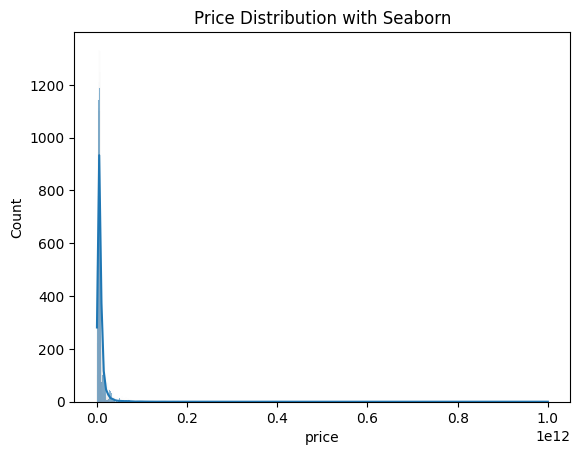

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=s_listing_df, x='price', kde=True)
plt.title('Price Distribution with Seaborn')
plt.show()

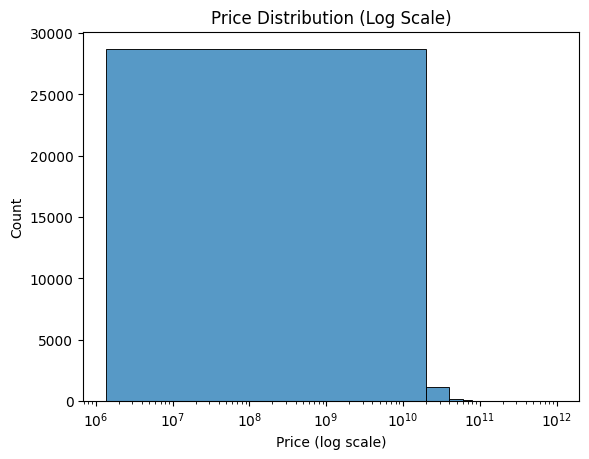

In [33]:
plt.figure()
sns.histplot(s_listing_df['price'], bins=50)
plt.xscale("log")
plt.xlabel("Price (log scale)")
plt.title("Price Distribution (Log Scale)")
plt.show()

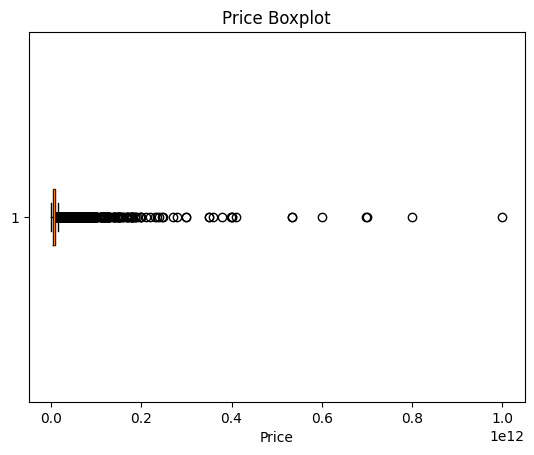

In [34]:
plt.figure()
plt.boxplot(s_listing_df['price'], vert=False)
plt.xlabel("Price")
plt.title("Price Boxplot")
plt.show()

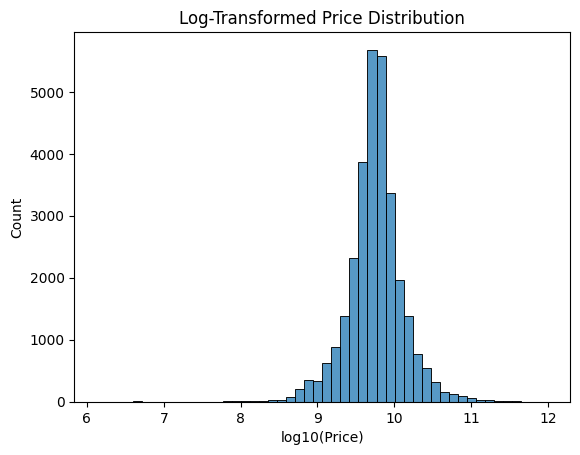

In [35]:
import numpy as np

log_price = np.log10(s_listing_df['price'])

plt.figure()
sns.histplot(log_price, bins=50)
plt.xlabel("log10(Price)")
plt.title("Log-Transformed Price Distribution")
plt.show()

In [36]:
s_listing_df[s_listing_df['price'] > 1e10][['account_name', 'body', 'price', 'list_id']]

,account_name,body,price,list_id
15,THIENHUONGLAND,BÁN DUPLEX SADORA – GIÁ TỐT HIẾM CÓ CHỈ ~156 T...,30000000000,129867829
110,Phúc Nguyễn Nhà Phố,BÁN CHDV hẻm 6m 1 trục thông thoáng gần mặt t...,15000000000,129861561
121,HUỲNH THÀNH XUÂN,"Bán căn hộ Penhouse Sky Garden 2, Phú Mỹ Hưng ...",17500000000,129861201
182,Thành Phạm Vincentral,"+ 3PN, 2WC, hướng Đông.\n+ Nội thất đầy đủ: Đi...",13000000000,129827617
197,Quốc Bảo,Bán CHDV 10 Phòng Thu nhập 780 Triệu / năm. Ph...,14500000000,129858706
...,...,...,...,...
30275,TranThu,Khu đất thổ cư 500m2 có nở hậu tọa lạc trong k...,38000000000,128274836
30276,Nguyễn Nhân Văn,Nền đất là lô góc 2 mặt tiền gần bệnh viện gần...,23000000000,128259365
30278,Hân Hân,"Đường rộng 10m, có lề 3m, cực thoáng – vị trí ...",15800000000,128254153
30279,Nguyễn Thuỷ,"*Giá: 10Tỷ5 \n*Diện Tích đất công nhận: 136,2...",10500000000,128250573


## 2.13 price vs size

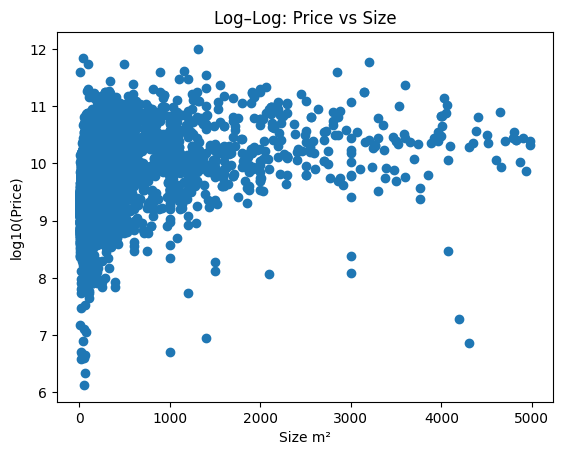

In [37]:
lower_5000_m2_df = s_listing_df[s_listing_df["size"] < 5000]

plt.figure()
plt.scatter(
    lower_5000_m2_df["size"],
    np.log10(lower_5000_m2_df["price"])
)
plt.xlabel("Size m²")
plt.ylabel("log10(Price)")
plt.title("Log–Log: Price vs Size")
plt.show()

## 2.14 Xử lý price_string

Cột để hiển thị về giá + đơn vị (triệu / tỷ)

Phân tích thêm có trường nào không có triệu / tỷ không !?

In [38]:
s_listing_df['price_string']

,price_string
0,"3,65 tỷ"
1,"2,4 tỷ"
2,"4,44 tỷ"
3,"2,18 tỷ"
4,"2,6 tỷ"
...,...
30279,"10,5 tỷ"
30280,"4,455 tỷ"
30281,2 tỷ
30282,11 tỷ


## 2.15 Xử lý property_legal_document

Xử lý từng loại giá trị 1,2,3,4,5,6,nan -> tên tình trạng giấy tờ.

Drop ['property_legal_document']

In [39]:
s_listing_df['property_legal_document'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: property_legal_document
Non-Null Count  Dtype  
--------------  -----  
30276 non-null  float64
dtypes: float64(1)
memory usage: 236.7 KB


In [40]:
s_listing_df['property_legal_document'].unique()

array([ 6.,  2.,  5.,  4.,  1., nan,  3.])

In [41]:
mapping_property_legal_document = {
    1.0: "Đã có sổ",
    2.0: "Đang chờ sổ",
    3.0: "Giấy tờ khác",
    4.0: "Hợp đồng đặt cọc",
    5.0: "Hợp đồng mua bán",
    6.0: "Sổ hồng riêng",
    np.nan: "Không có thông tin"
}

In [42]:
s_listing_df[s_listing_df['property_legal_document'] == 6.0][['list_id', 'body', 'price']]

,list_id,body,price
0,129736089,"⭐ Giá bán: 3,65 tỷ (Bao full thuế phí)\n⭐ Diện...",3650000000
2,129653400,"🏡 Bán căn hộ 113m² - Giá bán 4,44 tỷ - Ban côn...",4440000000
3,129868760,"✅Dt: 45,3m2.Thiết kế 1PN, 1WC, phòng khách, bế...",2180000000
4,128288282,Căn hộ 2PN 2WC. Diện tích: 59m² (TT 54.5m²).\n...,2600000000
5,129868648,Bán căn hộ 2 phòng ngủ chung cư Pegasuite I Ph...,4800000000
...,...,...,...
29845,129319134,Nhà xa mua lâu rồi ko xuống ở\n\nLÔ ĐẤT 5.14 d...,1500000000
29923,129295467,Đất đã đổ nền giấy tờ viết tay có công chứng n...,220000000
30116,128862406,Đất LÔ GÓC DT 4x15=60m2\n. Tình trạng giấy tay...,1150000000
30181,128600978,Ib trực tiếp sẽ đưa thêm thông tin. Giá còn th...,600000000


In [43]:
s_listing_df["property_legal_document_status"] = s_listing_df["property_legal_document"].map(mapping_property_legal_document)

In [44]:
s_listing_df["property_legal_document_status"].unique()

array(['Sổ hồng riêng', 'Đang chờ sổ', 'Hợp đồng mua bán',
       'Hợp đồng đặt cọc', 'Đã có sổ', 'Không có thông tin',
       'Giấy tờ khác'], dtype=object)

In [45]:
# s_listing_df.drop(columns=['s_listing_df'], inplace=True)

## 2.16 protection_entitlement

Tất cả đều là True -> bỏ.

Drop ['protection_entitlement']

In [46]:
s_listing_df['protection_entitlement'].unique()

array([False,  True])

In [47]:
# s_listing_df.drop(columns=['protection_entitlement'], inplace=True)

## 2.17 pty_map, pty_map_modifier

pty_map: hình ảnh trên bản đồ sử dụng Openstreetmap

pty_map_modifier: một thông số tất cả đều là 0.0008 -> Bỏ

Drop ['pty_map_modifier']

In [48]:
s_listing_df['pty_map_modifier'].unique()

array([0.0008])

In [49]:
# s_listing_df.drop(columns=['pty_map_modifier'], inplace=True)

## 2.18 region, region_name, region_v2

Hiển thị thông tin khu vực đang xem, hiện tại vì đã lọc của TP Hồ Chí Minh nên tất cả giá trị đều giống nhau -> Bỏ.

Drop ['region', 'region_name', 'region_v2']

In [50]:
s_listing_df['region'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: region
Non-Null Count  Dtype
--------------  -----
30284 non-null  int64
dtypes: int64(1)
memory usage: 236.7 KB


In [51]:
s_listing_df['region'].unique()

array([13])

In [52]:
# s_listing_df.drop(columns=['region', 'region_name', 'region_v2'], inplace=True)

## 2.19 rooms

rooms hiển thị số phòng.

Số phòng của bất động sản
{
          "id": "1",
          "value": "1"
        },
        {
          "id": "2",
          "value": "2"
        },
        {
          "id": "3",
          "value": "3"
        },
        {
          "id": "4",
          "value": "4"
        },
        {
          "id": "5",
          "value": "5"
        },
        {
          "id": "6",
          "value": "6"
        },
        {
          "id": "7",
          "value": "7"
        },
        {
          "id": "8",
          "value": "8"
        },
        {
          "id": "9",
          "value": "9"
        },
        {
          "id": "10",
          "value": "10"
        },
        {
          "id": "11",
          "value": "nhiều hơn 10"
        }

Tạo ra cột mới ['rooms_count']

Drop ['rooms']

In [53]:
s_listing_df['rooms'].unique()

array([ 3.,  1.,  2.,  4., 11.,  5., 10.,  6.,  8.,  7.,  9., nan])

In [54]:
mapping_rooms = {
    1.0: "1",
    2.0: "2",
    3.0: "3",
    4.0: "4",
    5.0: "5",
    6.0: "6",
    7.0: "7",
    8.0: "8",
    9.0: "9",
    10.0: "10",
    11.0: "nhiều hơn 10",
    np.nan: "Không có thông tin"
}

In [55]:
s_listing_df["rooms_count"] = s_listing_df['rooms'].map(mapping_rooms)

In [56]:
s_listing_df["rooms_count"]

,rooms_count
0,3
1,1
2,3
3,2
4,2
...,...
30279,Không có thông tin
30280,Không có thông tin
30281,Không có thông tin
30282,Không có thông tin


In [57]:
# s_listing_df.drop(columns=['rooms'], inplace=True)

## 2.20 Xử lý size, size_unit_string

Size là giá trị diện tích của bđs.

size_unit_string là đơn vị, tất cả đều là m2 -> Bỏ

Drop ['size_unit_string']

In [58]:
s_listing_df['size'].describe()

,size
count,30284.000000
mean,156.851421
std,1608.977831
min,4.000000
25%,50.000000
50%,66.500000
75%,100.000000
max,210000.000000


In [59]:
s_listing_df['size_unit_string'].unique()

array(['m²', 'hecta'], dtype=object)

In [60]:
# s_listing_df.drop(columns=['size_unit_string'], inplace=True)

## 2.21 Xử lý special_display_images

Hình ảnh quảng cáo của bđs -> Bỏ

Drop ['special_display_images']

In [61]:
s_listing_df[['special_display_images', 'list_id']]

,special_display_images,list_id
0,['https://cdn.chotot.com/DSbhraW9eVv11hEAfm84L...,129736089
1,[],129868846
2,[],129653400
3,[],129868760
4,[],128288282
...,...,...
30279,[],128250573
30280,[],128248486
30281,[],128243293
30282,[],128236377


In [62]:
s_listing_df.iloc[4]['special_display_images']

'[]'

In [63]:
# s_listing_df.drop(columns=['special_display_images'], inplace=True)

## 2.22 Xử lý state và status

Cả 2 chỉ có giá trị 'accepted' cho state và 'active' cho status -> Bỏ

Drop ['state', 'status']

In [64]:
s_listing_df['state'].unique()

array(['accepted'], dtype=object)

In [65]:
s_listing_df['status'].unique()

array(['active'], dtype=object)

## 2.23 Xử lý thumbnail_image

Ảnh bìa của bài đăng, có một số lượng nhỏ bị null -> Có thể phân tích thêm.


In [66]:
s_listing_df.loc[0, 'account_name']

'Minh Hiếu'

In [67]:
s_listing_df.iloc[0]

,0
account_id,15769554
account_name,Minh Hiếu
account_oid,b8abd37007704fd2ca7a0948d19ecb74
apartment_type,1.0
area,115
...,...
orig_datetime,2025-12-17 05:58:12+00:00
datetime,2025-12-23 17:24:18+00:00
apartment_type_name,Chung cư
property_legal_document_status,Sổ hồng riêng


In [68]:
s_listing_df['thumbnail_image'].iloc[0]

'https://cdn.chotot.com/JS72TaLm1MdC1BY5AT0rvBhb8DADhkoYe0l4YdfrFz4/preset:listing/plain/65ad1082a6d8b1b45d0295476385f17a-2962774164300977196.jpg'

In [69]:
s_listing_df['thumbnail_image'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: thumbnail_image
Non-Null Count  Dtype 
--------------  ----- 
30147 non-null  object
dtypes: object(1)
memory usage: 236.7+ KB


## 2.24 Xử lý toilets

Số lượng phòng WC (toilet)
{
          "id": "1",
          "value": "1"
        },
        {
          "id": "2",
          "value": "2"
        },
        {
          "id": "3",
          "value": "3"
        },
        {
          "id": "4",
          "value": "4"
        },
        {
          "id": "5",
          "value": "5"
        },
        {
          "id": "6",
          "value": "6"
        },
        {
          "id": "7",
          "value": "Nhiều hơn 6"
        }

Drop ['toilets']

In [70]:
s_listing_df['toilets'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: toilets
Non-Null Count  Dtype  
--------------  -----  
18819 non-null  float64
dtypes: float64(1)
memory usage: 236.7 KB


In [71]:
s_listing_df['toilets'].unique()

array([ 2.,  1., nan,  3.,  4.,  7.,  6.,  5.])

In [72]:
mapping_toilets = {
    1.0: "1",
    2.0: "2",
    3.0: "3",
    4.0: "4",
    5.0: "5",
    6.0: "6",
    7.0: "Nhiều hơn 6",
    np.nan: "Không có thông tin"
}

In [73]:
s_listing_df['toilets_count'] = s_listing_df['toilets'].map(mapping_toilets)

In [74]:
s_listing_df['toilets_count']

,toilets_count
0,2
1,1
2,2
3,1
4,2
...,...
30279,Không có thông tin
30280,Không có thông tin
30281,Không có thông tin
30282,Không có thông tin


In [75]:
# s_listing_df.drop(columns=['toilets'], inplace=True)

## 2.25 Xử lý type

Có thể bỏ vì nó đang hiển thị cho "s" - mua bán hay "u" - cho thuê -> Có thể bỏ

Drop ['type']

In [76]:
s_listing_df['type'].unique()

array(['s'], dtype=object)

In [77]:
# s_listing_df.drop(columns=['type'], inplace=True)

## 2.26 ward, ward_name

Có thể bỏ ward, chỉ sử dụng ward_name

Drop ['ward']

In [78]:
s_listing_df[['ward', 'ward_name']]

,ward,ward_name
0,9509,Thị trấn Tân Túc
1,9251,Phường Long Thạnh Mỹ (Quận 9 cũ)
2,9509,Thị trấn Tân Túc
3,9452,Phường 6
4,9509,Thị trấn Tân Túc
...,...,...
30279,9260,Phường Long Trường (Quận 9 cũ)
30280,9455,Phường 7
30281,9493,Xã Tân Thạnh Đông
30282,9258,Phường Trường Thạnh (Quận 9 cũ)


In [79]:
# s_listing_df.drop(columns=['ward'], inplace=True)

## 2.27 average_rating, average_rating_for_seller, total_rating, total_rating_for_seller

In [80]:
s_listing_df['average_rating'].describe()

,average_rating
count,10890.000000
mean,4.564830
std,0.824322
min,1.000000
25%,4.500000
50%,5.000000
75%,5.000000
max,5.000000


In [81]:
s_listing_df['average_rating'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: average_rating
Non-Null Count  Dtype  
--------------  -----  
10890 non-null  float64
dtypes: float64(1)
memory usage: 236.7 KB


In [82]:
s_listing_df['average_rating_for_seller'].describe()

,average_rating_for_seller
count,8999.000000
mean,4.475742
std,0.970891
min,1.000000
25%,4.300000
50%,5.000000
75%,5.000000
max,5.000000


In [83]:
s_listing_df['average_rating_for_seller'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: average_rating_for_seller
Non-Null Count  Dtype  
--------------  -----  
8999 non-null   float64
dtypes: float64(1)
memory usage: 236.7 KB


In [84]:
s_listing_df[s_listing_df['average_rating_for_seller'] <= 2.0][['list_id', 'account_name', 'average_rating', 'average_rating_for_seller', 'total_rating_for_seller']]

,list_id,account_name,average_rating,average_rating_for_seller,total_rating_for_seller
89,123751381,HANG,3.0,1.0,1.0
102,129235191,ĐẶNG HẰNG,3.0,1.0,1.0
104,125018997,HANG,3.0,1.0,1.0
119,129654737,ĐẶNG HẰNG,3.0,1.0,1.0
528,128956555,Trương Hồng Ngà,1.0,1.0,1.0
...,...,...,...,...,...
29673,129335123,Trung,1.0,1.0,1.0
29694,129332517,Hoàng Sĩ Lực,1.0,1.0,1.0
29853,124176308,Anh Tâm,3.0,1.0,1.0
29854,121824191,Tâm BĐS,3.0,1.0,1.0


In [85]:
s_listing_df['total_rating'].describe()

,total_rating
count,10890.000000
mean,4.644169
std,8.800417
min,1.000000
25%,1.000000
50%,2.000000
75%,5.000000
max,336.000000


## 2.28 Xử lý company_ad

Chỉ có 2 giá trị là True / nan.

In [86]:
s_listing_df['company_ad'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: company_ad
Non-Null Count  Dtype 
--------------  ----- 
26593 non-null  object
dtypes: object(1)
memory usage: 236.7+ KB


In [87]:
s_listing_df['company_ad'].unique()

array([True, nan], dtype=object)

In [88]:
s_listing_df[s_listing_df['company_ad'].isna()][['list_id', 'account_name', 'body', 'price']]

,list_id,account_name,body,price
1,129868846,dang tuong vy,Origami. Vinhome grand park q9\n1pn.chính chu ...,2400000000
3,129868760,Đoàn minh hùng,"✅Dt: 45,3m2.Thiết kế 1PN, 1WC, phòng khách, bế...",2180000000
5,129868648,Minh Đức Nhà thật giá trị thật,Bán căn hộ 2 phòng ngủ chung cư Pegasuite I Ph...,4800000000
8,129868462,Mỹ Lành,Ngộp Bank cần bán gấp căn hộ 1PN+ khu The Beve...,2670000000
10,129868188,Vũ Khắc Ly,Cần bán căn hộ chung cư Dreamhome Luxury \nĐịa...,2200000000
...,...,...,...,...
30279,128250573,Nguyễn Thuỷ,"*Giá: 10Tỷ5 \n*Diện Tích đất công nhận: 136,2...",10500000000
30280,128248486,Huy,"Cần bán đất trống ngay khu vực chợ Bình Điền, ...",4455000000
30281,128243293,Tony,Cần bán đất 379 nguyen kim cuong cu chi nhanh ...,2000000000
30282,128236377,Trịnh Hữu Khánh,Cần bán đất nền quận 9 cũ thông tin pháp lý đầ...,11000000000


## 2.29 Xử lý furnishing_sell

Xử lý các giá trị furnishing_sell về nội thất

Drop ['furnishing_sell']

In [89]:
s_listing_df['furnishing_sell'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: furnishing_sell
Non-Null Count  Dtype  
--------------  -----  
12358 non-null  float64
dtypes: float64(1)
memory usage: 236.7 KB


In [90]:
s_listing_df['furnishing_sell'].unique()

array([ 2.,  3., nan,  1.,  4.])

In [91]:
s_listing_df[s_listing_df['furnishing_sell'] == 4.0][['list_id', 'body', 'price']]

,list_id,body,price
154,127375431,"BÁN CĂN HỘ 2PN 75m² LAVIDA PLUS – GIÁ CHỈ 4,5 ...",4650000000
161,129838738,CĂN HỘ TRUNG TÂM SÀI GÒN – CHỈ CẦN 900 TRIỆU –...,3600000000
550,129831824,👉👉 < Bình Thạnh >\nCần bán chung cư 1050 Phan ...,3500000000
989,129789456,"Chung cư ở địa chỉ 318 hươngblooj 80 , vĩnh lộ...",1350000000
1001,129788741,"Nhà rẻ lắm ạ, cách green 2km\n 930tr 42m2 , 1....",1350000000
...,...,...,...
24302,129406095,Mặt tiên đường 12m diện tích 12 x 27 đất ở nôn...,13000000000
24304,129432472,Bán căn Shophoue khối đế 2 tầng dự án Picity H...,6800000000
24326,129381965,Bán Nhà Mặt Tiền Đường Phan Huy ích Phường 15 ...,35000000000
24387,126908367,"Mặt tiền 392A- 392B Mã Lò, Phường Bình Trị Đôn...",56000000000


In [92]:
mapping_furnishing_sell = {
    1.0: "Nội thất cao cấp",
    2.0: "Nội thất đầy đủ",
    3.0: "Hoàn thiện cơ bản",
    4.0: "Bàn giao thô",
    np.nan: "Không có thông tin"
}

In [93]:
s_listing_df['furnishing_sell_status'] = s_listing_df['furnishing_sell'].map(mapping_furnishing_sell)

In [94]:
s_listing_df['furnishing_sell_status']

,furnishing_sell_status
0,Nội thất đầy đủ
1,Hoàn thiện cơ bản
2,Nội thất đầy đủ
3,Không có thông tin
4,Nội thất đầy đủ
...,...
30279,Không có thông tin
30280,Không có thông tin
30281,Không có thông tin
30282,Không có thông tin


## 2.30 Xử lý balconydirection, direction

Thông tin về hướng ban công, null nhiều.
Thông tin về hướng nhà.

{
          "id": "1",
          "value": "Đông"
        },
        {
          "id": "2",
          "value": "Tây"
        },
        {
          "id": "3",
          "value": "Nam"
        },
        {
          "id": "4",
          "value": "Bắc"
        },
        {
          "id": "5",
          "value": "Đông Bắc"
        },
        {
          "id": "6",
          "value": "Đông Nam"
        },
        {
          "id": "7",
          "value": "Tây Bắc"
        },
        {
          "id": "8",
          "value": "Tây Nam"
        }

Drop ['balconydirection', 'direction']

In [95]:
s_listing_df['balconydirection'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: balconydirection
Non-Null Count  Dtype  
--------------  -----  
952 non-null    float64
dtypes: float64(1)
memory usage: 236.7 KB


In [96]:
s_listing_df['balconydirection'].unique()

array([nan,  7.,  3.,  1.,  8.,  6.,  5.,  2.,  4.])

In [97]:
mapping_direction = {
    1.0: "Đông",
    2.0: "Tây",
    3.0: "Nam",
    4.0: "Bắc",
    5.0: "Đông Bắc",
    6.0: "Đông Nam",
    7.0: "Tây Bắc",
    8.0: "Tây Nam",
    np.nan: "Không có thông tin"
}

In [98]:
s_listing_df["balconydirection_name"] = s_listing_df['balconydirection'].map(mapping_direction)

In [99]:
s_listing_df['direction'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: direction
Non-Null Count  Dtype  
--------------  -----  
6857 non-null   float64
dtypes: float64(1)
memory usage: 236.7 KB


In [100]:
s_listing_df["direction_name"] = s_listing_df["direction"].map(mapping_direction)

In [101]:
s_listing_df[["list_id", "body", "price", "balconydirection_name", "direction_name"]]

,list_id,body,price,balconydirection_name,direction_name
0,129736089,"⭐ Giá bán: 3,65 tỷ (Bao full thuế phí)\n⭐ Diện...",3650000000,Không có thông tin,Không có thông tin
1,129868846,Origami. Vinhome grand park q9\n1pn.chính chu ...,2400000000,Không có thông tin,Không có thông tin
2,129653400,"🏡 Bán căn hộ 113m² - Giá bán 4,44 tỷ - Ban côn...",4440000000,Tây Bắc,Không có thông tin
3,129868760,"✅Dt: 45,3m2.Thiết kế 1PN, 1WC, phòng khách, bế...",2180000000,Không có thông tin,Không có thông tin
4,128288282,Căn hộ 2PN 2WC. Diện tích: 59m² (TT 54.5m²).\n...,2600000000,Nam,Bắc
...,...,...,...,...,...
30279,128250573,"*Giá: 10Tỷ5 \n*Diện Tích đất công nhận: 136,2...",10500000000,Không có thông tin,Nam
30280,128248486,"Cần bán đất trống ngay khu vực chợ Bình Điền, ...",4455000000,Không có thông tin,Không có thông tin
30281,128243293,Cần bán đất 379 nguyen kim cuong cu chi nhanh ...,2000000000,Không có thông tin,Không có thông tin
30282,128236377,Cần bán đất nền quận 9 cũ thông tin pháp lý đầ...,11000000000,Không có thông tin,Không có thông tin


In [102]:
# s_listing_df.drop(column=['balconydirection', 'direction'], inplace=True)

## 2.31 is_block_similar_ads_other_agent

Null nhiều, không có nhiều ý nghĩa -> Bỏ

Drop ['is_block_similar_ads_other_agent']

In [103]:
s_listing_df['is_block_similar_ads_other_agent'].info()


<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: is_block_similar_ads_other_agent
Non-Null Count  Dtype 
--------------  ----- 
906 non-null    object
dtypes: object(1)
memory usage: 236.7+ KB


In [104]:
s_listing_df['is_block_similar_ads_other_agent'].unique()

array([True, nan], dtype=object)

## 2.32 special_display, stickyad_feature

special_display số lượng null nhiều, chỉ có 2 giá trị True / nan

stickyad_feature là giá trị 'special_display' khi special_display là True.

Có thể giữ lại 1 trong 2 cột.

In [105]:
s_listing_df['special_display'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: special_display
Non-Null Count  Dtype 
--------------  ----- 
3067 non-null   object
dtypes: object(1)
memory usage: 236.7+ KB


In [106]:
s_listing_df['special_display'].unique()

array([True, nan], dtype=object)

In [107]:
s_listing_df['stickyad_feature'].unique()

array(['special_display', nan], dtype=object)

In [108]:
s_listing_df[['special_display', 'stickyad_feature']]

,special_display,stickyad_feature
0,True,special_display
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
30279,NaN,NaN
30280,NaN,NaN
30281,NaN,NaN
30282,NaN,NaN


## 2.33 Xử lý apartment_feature

Giá trị bị null khá nhiều -> Có thể cân nhắc bỏ

Drop ['apartment_feature']

In [109]:
s_listing_df['apartment_feature'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: apartment_feature
Non-Null Count  Dtype  
--------------  -----  
595 non-null    float64
dtypes: float64(1)
memory usage: 236.7 KB


In [110]:
s_listing_df['apartment_feature'].unique()

array([nan,  1.,  0.])

In [111]:
s_listing_df[s_listing_df['apartment_feature'] == 1.0]

,account_id,account_name,account_oid,apartment_type,area,area_name,area_v2,body,category,category_name,...,size_unit,orig_datetime,datetime,apartment_type_name,property_legal_document_status,rooms_count,toilets_count,furnishing_sell_status,balconydirection_name,direction_name
30,995336,Hạnh Nguyễn,8d23b35bddc871c6455ef8d48e774caf,1.0,108,Quận Bình Tân,13108,"💥💥 Chính chủ thiện chí bán nhà sạch, đẹp.\n\n👉...",1010,Căn hộ/Chung cư,...,NaN,NaT,2025-12-23 13:11:48+00:00,Chung cư,Đang chờ sổ,2,1,Nội thất đầy đủ,Không có thông tin,Không có thông tin
50,19595852,Lee Ngoc Diem,51dd47e1fefcea6830cc43e419ec68a8,1.0,103,Quận 8,13103,🔴Bán căn góc 2PN view Q1 🔴\n\n- Chung cư TARA ...,1010,Căn hộ/Chung cư,...,NaN,NaT,2025-12-23 11:32:26+00:00,Chung cư,Sổ hồng riêng,2,2,Không có thông tin,Không có thông tin,Không có thông tin
57,21856904,Khangphuc,871f32b0611efc23600d235565334d2a,1.0,103,Quận 8,13103,"Bán căn hộ tầng trệt tại chung cư "" Green Rive...",1010,Căn hộ/Chung cư,...,NaN,NaT,2025-12-23 11:12:31+00:00,Chung cư,Sổ hồng riêng,2,3,Hoàn thiện cơ bản,Không có thông tin,Không có thông tin
59,9967852,Việt Thanh,1e3f322cd656e37513f90bad07957b64,1.0,119,Thành phố Thủ Đức,13119,Căn hộ CitiAlto nằm trong Khu đô thị Cát Lái Q...,1010,Căn hộ/Chung cư,...,NaN,2025-12-12 07:33:25+00:00,2025-12-23 11:06:03.648000+00:00,Chung cư,Hợp đồng mua bán,2,2,Không có thông tin,Không có thông tin,Không có thông tin
62,52045,NGUYỄN LÊ DIỄM TRANG,cb370f8c2b449e57d6599b3282bc552c,1.0,103,Quận 8,13103,Bán căn hộ Carina Plaza mặt tiền đường Võ Văn ...,1010,Căn hộ/Chung cư,...,NaN,NaT,2025-12-23 10:58:34+00:00,Chung cư,Sổ hồng riêng,2,2,Nội thất đầy đủ,Đông Bắc,Nam
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3908,405163,cty cp mua sắm hạnh phúc,a803fbf47a126169b7e4c84e565dae29,1.0,119,Thành phố Thủ Đức,13119,Chính chủ cần bán căn 3PN S5 Rainbow tầng trun...,1010,Căn hộ/Chung cư,...,NaN,NaT,2025-10-17 13:41:02+00:00,Chung cư,Sổ hồng riêng,3,2,Nội thất đầy đủ,Đông Nam,Không có thông tin
3917,23342833,Trang Pham,bdb05bbf8915265b3922588bd210c530,1.0,119,Thành phố Thủ Đức,13119,Vị trí đắc địa: Nằm tại Khu đô thị Nam Rạch Ch...,1010,Căn hộ/Chung cư,...,NaN,NaT,2025-10-16 02:45:58+00:00,Chung cư,Hợp đồng mua bán,2,2,Nội thất cao cấp,Đông,Nam
3946,12921176,BĐS Chính Chủ,c3d3e62b4f96ac18ff5032852bf50eda,6.0,102,Quận 7,13102,Chính chủ muốn bán nhanh căn hộ A1-16.01\nCăn ...,1010,Căn hộ/Chung cư,...,NaN,NaT,2025-10-10 08:39:30+00:00,Officetel,Hợp đồng mua bán,2,Không có thông tin,Hoàn thiện cơ bản,Đông Nam,Tây Bắc
3955,11392035,Tín,77029eff1ef9cc3b3a65e1cefd13652e,1.0,119,Thành phố Thủ Đức,13119,"BÁN CĂN HỘ BE2.13.12 – THE BEVERLY, VINHOMES G...",1010,Căn hộ/Chung cư,...,NaN,NaT,2025-10-08 06:14:39+00:00,Chung cư,Đang chờ sổ,2,2,Nội thất đầy đủ,Đông,Tây


## 2.34 Xử lý detail_address

Có thể bị thừa thông tin địa chỉ (đã có tên phường, tên quận, và toạ độ) -> Bỏ

Có một địa chỉ bị nhầm sang TP Thái Nguyên: Số 309 Đường Cách Mạng Tháng Tám, Phường Cải Đan, Sông Công, Thái Nguyên

Drop ['detail_address']

In [112]:
s_listing_df['detail_address'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: detail_address
Non-Null Count  Dtype 
--------------  ----- 
2170 non-null   object
dtypes: object(1)
memory usage: 236.7+ KB


In [113]:
s_listing_df['detail_address'].unique()

array(['Đường Tân Túc, Thị trấn Tân Túc, Bình Chánh, Hồ Chí Minh', nan,
       'Đường Trường Lưu, Phường Long Trường, TP Thủ Đức, TP HCM',
       'KĐT Vinhomes Grand Park, Phường Long Thạnh Mỹ, Quận 9, Hồ Chí Minh',
       'Đường Trần Hưng Đạo, Phường Nam Lý, Tp. Đồng Hới, Tỉnh Quảng Bình',
       'Đường Nguyễn Thị Định, Phường An Phú, Quận 2, Hồ Chí Minh',
       'Đường Xa Lộ Hà Nội, Phường Thảo Điền, Quận 2, Hồ Chí Minh',
       'Số 4 Đường Đào Trí',
       'Số 510 Số 510, Đường Kinh Dương Vương, Phường An Lạc A, Quận Bình Tân, TP . Hồ Chí Minh',
       'Đường Nguyễn Xiển', 'Đường Hoàng Diệu',
       'Đường Hoàng Diệu, Phường 8, Quận 4, Hồ Chí Minh',
       'số 88 Số 88 đường N1, phường Sơn Kỳ, quận Tân Phú, Tp.HCM',
       'số 1A Đường Tạ Quang Bửu',
       'Đường N1, Phường Sơn Kỳ, Quận Tân Phú, TP.HCM',
       'Số 2225 Đường Phạm Thế Hiển',
       'Phố Tạ Quang Bửu, Phường 5, Quận 8, Hồ Chí Minh',
       'Đường Nguyễn Thị Định',
       'Đường D7, Phường Phú Hữu, Quận 9, Hồ Chí Min

## 2.35 Xử lý project_oid, projectid

Có thể phân tích project thuộc dự án nào, tuy nhiên đây chỉ có thông tin id -> Bỏ một trong 2.

Số lượng projectid khá ít. Có thể phân tích các projectid có ảnh hưởng tới giá hoặc khu đất nào có ảnh hưởng.

Drop ['project_oid']

In [114]:
s_listing_df['project_oid'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: project_oid
Non-Null Count  Dtype  
--------------  -----  
3731 non-null   float64
dtypes: float64(1)
memory usage: 236.7 KB


In [115]:
s_listing_df['projectid'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: projectid
Non-Null Count  Dtype  
--------------  -----  
3731 non-null   float64
dtypes: float64(1)
memory usage: 236.7 KB


In [116]:
s_listing_df['projectid'].unique()

array([4.607e+03, 4.722e+03,       nan, 4.855e+03, 4.784e+03, 4.152e+03,
       2.624e+03, 1.387e+03, 4.811e+03, 4.788e+03, 4.000e+01, 2.446e+03,
       3.479e+03, 3.000e+02, 4.094e+03, 1.301e+03, 1.317e+03, 4.810e+02,
       2.011e+03, 1.636e+03, 1.351e+03, 1.270e+03, 1.544e+03, 5.400e+01,
       4.869e+03, 1.394e+03, 5.320e+02, 2.930e+02, 4.611e+03, 1.273e+03,
       5.300e+02, 4.377e+03, 1.284e+03, 4.854e+03, 4.200e+01, 1.000e+00,
       2.200e+01, 4.760e+02, 5.220e+02, 4.490e+02, 1.874e+03, 5.227e+03,
       1.827e+03, 2.325e+03, 5.120e+02, 5.325e+03, 1.300e+01, 2.440e+03,
       1.771e+03, 1.902e+03, 1.800e+03, 4.860e+02, 1.880e+02, 3.490e+03,
       1.568e+03, 1.946e+03, 4.439e+03, 5.000e+01, 3.814e+03, 4.480e+02,
       4.138e+03, 2.300e+01, 1.775e+03, 3.700e+01, 1.943e+03, 4.140e+03,
       2.330e+02, 1.762e+03, 4.360e+02, 4.764e+03, 3.624e+03, 5.290e+02,
       1.274e+03, 3.658e+03, 4.425e+03, 4.153e+03, 1.500e+03, 4.792e+03,
       1.859e+03, 1.296e+03, 1.484e+03, 3.830e+02, 

## 2.36 Xử lý pty_project_name

Có thể là tên của dự án mà bđs thuộc về. Số lượng null khá nhiều.

Ý tưởng để xử lý, có thể kiểm tra xem bđs này có thuộc 1 dự án nào không -> tăng tính uy tín.

In [117]:
s_listing_df['pty_project_name'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: pty_project_name
Non-Null Count  Dtype 
--------------  ----- 
3410 non-null   object
dtypes: object(1)
memory usage: 236.7+ KB


In [118]:
s_listing_df['pty_project_name'].unique()

array(['West Gate Park', 'The Origami – Vinhomes Grand Park', nan,
       'MT Eastmark City', 'The Beverly Solari - Vinhomes Grand Park',
       'Sky 89 An Gia', 'Sài Gòn Intela', 'Sadora Apartment',
       'Sunshine Sky City', 'Precia', 'Masteri Thảo Điền',
       'Imperial Place', 'Saigon Riverside Complex Q7',
       'Moonlight Boulevard', 'Flora Novia', 'Masteri An Phú',
       'Vinhomes Grand Park', 'Prosper Plaza',
       'Căn Hộ Cao Cấp H3 Hoàng Diệu', 'Cao Ốc Căn Hộ H2-Hoàng Diệu',
       'Celadon City', 'Tara Residence', 'Carina Plaza',
       'Sunrise CityView', 'Emerald Precinct', 'Green River - Quận 8',
       'Chung cư Bông Sao', 'Citi Soho', 'Ricca',
       'Diamond Riverside (City Gate Towers 2)', 'Citi Home', 'Citi Alto',
       'Chung cư Phú Mỹ', 'The Privia', 'Riva Park', 'Dream Home Palace',
       'Moonlight Park View', 'The Gold View', 'Charmington La Pointe',
       'Topaz Garden', 'Conic Đông Nam Á', 'Lavida Plus',
       'Green Town Bình Tân', 'The Pegasuite', '

## 2.37 Xử lý sold_ads

Đây là số lượng quảng cáo đã bán được của tài khoản đăng tin.

Số lượng null khá nhiều (50%). Có thể không ảnh hưởng trực tiếp tới giá bán. Tuy nhiên có thể sử dụng để lọc nhiễu.

In [119]:
s_listing_df['sold_ads'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: sold_ads
Non-Null Count  Dtype  
--------------  -----  
14831 non-null  float64
dtypes: float64(1)
memory usage: 236.7 KB


In [120]:
s_listing_df['sold_ads'].describe()

,sold_ads
count,14831.000000
mean,22.507113
std,157.722124
min,1.000000
25%,2.000000
50%,4.000000
75%,14.000000
max,3591.000000


## 2.38 Xử lý address

Chỉ có một số giá trị address (đa số null) -> Có thể bỏ

Drop ['address']

In [121]:
s_listing_df['address'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: address
Non-Null Count  Dtype 
--------------  ----- 
485 non-null    object
dtypes: object(1)
memory usage: 236.7+ KB


In [122]:
s_listing_df['address'].unique()

array([nan, 'số 1A Đường Tạ Quang Bửu', 'Đường Nguyễn Thị Định',
       'Đường Đại Lộ Đông Tây, Phường 16, Quận 8, Hồ Chí Minh',
       'Đường Huỳnh Bá Chánh',
       '146 146 Nguyễn Văn Trỗi và 223 – 223B Hoàng Văn Thụ, Phú Nhuận, Hồ Chí Minh',
       'Đường Nguyễn Văn Linh, Phường Tân Thuận Tây,  Quận 7, Hồ Chí Minh',
       '16 Nguyễn Đức Thuận, phường 13, quận Tân Bình, Hồ Chí Minh',
       'Nguyễn Văn Linh', 'Đường Nguyễn Xiển',
       'số 59 Đường 57, phường 14, quận Gò Vấp, Tp.HCM',
       'Số 4 Đường Đào Trí', 'Đường Tân Túc',
       'Đường DC13, Phường Sơn Kỳ, Tân Phú, Hồ Chí Minh',
       'Đường Nguyễn Lương Bằng, Phường Phú Mỹ, Quận 7, Hồ Chí Minh',
       'Mặt tiền đường Phạm Văn Đồng, Phường Hiệp Bình Chánh, Quận Thủ Đức, Thành phố Hồ Chí Minh',
       'khu dân cư Nam Rạch Chiếc, phường An Phú, Quận 2, TP Thủ Đức',
       'Long Thạnh Mỹ', 'Đào Trí', 'Quốc lộ 1A', 'Đường Vũ Huy Tấn',
       'Trịnh Quang Nghị', 'Bình Hưng Hòa B', 'Tạ Quang Bửu', '7',
       'Vũ Huy Tấn', 'Tr

## 2.39 Xử lý has_video

Thể hiện thông tin bài đăng có kèm videos (null nhiều)

In [123]:
s_listing_df['has_video'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: has_video
Non-Null Count  Dtype 
--------------  ----- 
3374 non-null   object
dtypes: object(1)
memory usage: 236.7+ KB


In [124]:
s_listing_df['has_video'].unique()

array([nan, True], dtype=object)

## 2.40 Xử lý block

Tên block của dự án (null rất nhiều) -> Bỏ

Drop ['block']

In [125]:
s_listing_df['block'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: block
Non-Null Count  Dtype 
--------------  ----- 
1090 non-null   object
dtypes: object(1)
memory usage: 236.7+ KB


In [126]:
s_listing_df['block'].unique()

array([nan, 'B', 'BS15', 'C', 'A', '2B', 'AK9', 'AK7', 'B1', 'MP9X', 'B2',
       'ct1', 'T10', '4B', 'S301', 'Block B', 'S1.02', 'F', 'T1A', 'H4',
       'Bahamas', 'A1', 'b', 'E', 'D', 'Landmark 1', 'GH6', '1', '9',
       'cn2-2', 'S902A', 'Park 5', 'E2', 'iris 4', 'Cielo', 'A2', 'GH1',
       'E1', 'a', 'C1', 's8.02', 'B4', 'Park 2', 'Oasis ', '3A',
       'An Hòa 4', '3', 'A-B', 'G', 'Ak3', 'Ak7', 'W1', 'S705', 'A5',
       'C7', 'T2', 'A0', 'S302', 'Lake', 'Neo', 'GH 3', 'v7', 'Ak2', '9D',
       'Vinci', 'H', 'B3', 'S', 'S6.05', 'S606', 'c', '10', '09', '11',
       'C2', 'b3', 'OS5', 'Block C ', 'TW11', 's7', 'venus', 'BS10',
       'Aqua 1', 'A1.1', 'BS9', 'Lux 6', 'Mp9', 'CT3', 'orchid', 's2.01',
       'L', 'B5', 'Tháp 5', 'K', '20', 'T8', 'Tháp 7', 'O1', 'BE2',
       'cielo', '105', 'A3', '678', 'S7', 'The Alpha Reseidence', 'M2',
       'S203', 'S602', 'Bs5', 'S7.02', '2', 'TC1', 'B-C', 'Park 3', 'M',
       'LôA', 'V1', 'A4', 'S902', 'lake', 'BLOCK B', 'S10.05',
       '

## 2.41 pty_jupiter

In [127]:
s_listing_df['pty_jupiter'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: pty_jupiter
Non-Null Count  Dtype
--------------  -----
30284 non-null  int64
dtypes: int64(1)
memory usage: 236.7 KB


In [128]:
s_listing_df['pty_jupiter'].unique()

array([0])

## 2.42 Xử lý unitnumber, unitnumber_display

Cả 2 trường đều có số lượng null khá nhiều, chưa biết rõ ý nghĩa -> Bỏ

Drop ['unitnumber', 'unitnumber_display']



In [129]:
s_listing_df['unitnumber_display'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: unitnumber_display
Non-Null Count  Dtype  
--------------  -----  
9826 non-null   float64
dtypes: float64(1)
memory usage: 236.7 KB


In [130]:
s_listing_df['unitnumber_display'].unique()

array([ 0., nan,  1.])

In [131]:
s_listing_df['unitnumber'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: unitnumber
Non-Null Count  Dtype 
--------------  ----- 
1025 non-null   object
dtypes: object(1)
memory usage: 236.7+ KB


In [132]:
s_listing_df['unitnumber'].unique()

array([nan, 'S6.02', 'BS', 'B09.11', '4', 'B', '15', 'B1.27', 'S902',
       '24', '8', '23', 'BS802.23', 'S303', '01', '19.08', 'B5-12', 'F5',
       '14.20', 'T1A.18-09', 'A1.20.04', '16', 'E2-2201', '17', 'A', '08',
       'GH6.07.03', 'A1005', '1', '3', '1524', 'A1010', 'A8-2', 'T5',
       '14-01', '06', '10', 'v', 'G11', '213', '04', '304', '0808',
       '11.03', '6', 'LO A', '123', '12A-02', 'BS11.22.18', 'A2508', '02',
       'A514 ', 'B1-02', '03', '05.09', '2', '107', 'A13', 'A508', '21',
       'A 202', 'GH3-17.18', 'A808', '10.17', '0.01', 'B2-01-11', 'A08',
       'VNT32AD3B', '0207', 'C503', 'h', 'B08.10', '9', 'Xx a.17.10',
       '8.14', '301', '09', 'A3.09.19', 'TW11-6-05', '55', 'c102', '1x',
       '19.5', '5', 'b', 'SHLDT.6T', 'E.06.18', 'v2', 'g', 'S6.0502.10',
       'D-05-15', 'BS916.11', 'E', '11.06', '12', '0317', 'D07', '1001',
       'C09.10', '1002', '5-9', '0.12', 'd8', 'B2', '05', 'C', '25',
       'C.16.03', '11', 'b2 4.10', '10.01', 'D5', '5.16', '1354.

## 2.43 Xử lý floornumber

Giá trị null khá nhiều, có thể chỉ sử dụng được cho những căn hộ chung cư cao tầng -> Có thể cân nhắc sử dụng

In [133]:
s_listing_df['floornumber'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: floornumber
Non-Null Count  Dtype  
--------------  -----  
792 non-null    float64
dtypes: float64(1)
memory usage: 236.7 KB


In [134]:
s_listing_df['floornumber'].unique()

array([nan,  9.,  1., 24.,  4., 22., 15., 10., 27., 28.,  2.,  8.,  5.,
       20., 17., 16., 19.,  7.,  3., 14., 18., 12., 11., 29.,  6., 33.,
       21., 32., 13., 46., 25., 26., 34., 23., 31., 88., 55., 66., 36.,
       39., 30.])

In [135]:
s_listing_df[s_listing_df['floornumber'].notna()]

,account_id,account_name,account_oid,apartment_type,area,area_name,area_v2,body,category,category_name,...,size_unit,orig_datetime,datetime,apartment_type_name,property_legal_document_status,rooms_count,toilets_count,furnishing_sell_status,balconydirection_name,direction_name
1,663094,dang tuong vy,3fa9649369097f86c8ef3daa0555b546,1.0,119,Thành phố Thủ Đức,13119,Origami. Vinhome grand park q9\n1pn.chính chu ...,1010,Căn hộ/Chung cư,...,NaN,NaT,2025-12-23 17:11:53+00:00,Chung cư,Đang chờ sổ,1,1,Hoàn thiện cơ bản,Không có thông tin,Không có thông tin
6,18209033,Huỳnh Thanh Phong,f78c9ad1d4c65eedc81ada21208c2d45,1.0,119,Thành phố Thủ Đức,13119,Cần bán shophouse 124m2 2PN2WC - giá 7.68 tỷ t...,1010,Căn hộ/Chung cư,...,NaN,NaT,2025-12-23 16:20:14+00:00,Chung cư,Sổ hồng riêng,2,2,Hoàn thiện cơ bản,Đông,Tây
8,28060169,Mỹ Lành,0d4d241954841766285dcc9f631d6818,1.0,119,Thành phố Thủ Đức,13119,Ngộp Bank cần bán gấp căn hộ 1PN+ khu The Beve...,1010,Căn hộ/Chung cư,...,NaN,NaT,2025-12-23 16:06:08+00:00,Chung cư,Hợp đồng mua bán,1,1,Hoàn thiện cơ bản,Tây Nam,Đông
26,2732042,Đức Hòa,68f2a6c8715b3decb551c5faafe5dbcb,1.0,109,Quận Bình Thạnh,13109,⸻\n\n🔥 BÁN CĂN HỘ CHUNG CƯ BÌNH THẠNH – GIÁ TỐ...,1010,Căn hộ/Chung cư,...,NaN,NaT,2025-12-23 14:13:28+00:00,Chung cư,Sổ hồng riêng,2,1,Hoàn thiện cơ bản,Tây Nam,Đông Nam
60,30549469,Mai Văn Tuấn,4f209a830a79f4881bed8a44a54d28d7,1.0,102,Quận 7,13102,Chính chủ full nội thất 80 mét ở ngay Ai thuê ...,1010,Căn hộ/Chung cư,...,NaN,NaT,2025-12-23 11:00:34+00:00,Chung cư,Sổ hồng riêng,2,2,Nội thất đầy đủ,Không có thông tin,Không có thông tin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24389,15877566,VuCong,1af0408b55e75d5f34de1fb7ad69c273,NaN,119,Thành phố Thủ Đức,13119,"Khu vực kinh doanh phù hợp kd cafe quán ăn, sp...",1030,"Văn phòng, Mặt bằng kinh doanh",...,NaN,NaT,2025-11-04 05:00:02+00:00,Không có thông tin,Đã có sổ,Không có thông tin,Không có thông tin,Nội thất đầy đủ,Không có thông tin,Tây Bắc
24402,14975901,phượng,5b0eab9a609f0a36688e561b22cffa75,NaN,119,Thành phố Thủ Đức,13119,Mặt bằng kinh doanh 250 m² quốc lộ 13 Hiệp Bìn...,1030,"Văn phòng, Mặt bằng kinh doanh",...,NaN,NaT,2025-10-21 13:42:19+00:00,Không có thông tin,Đã có sổ,Không có thông tin,Không có thông tin,Hoàn thiện cơ bản,Không có thông tin,Đông Nam
24405,4784392,Nguyễn Thị Thanh Loan,718bc73235170261952e560c52988df3,NaN,107,Quận 12,13107,Bán Kios trong Chợ gần khu ăn uống sầm uất vớ...,1030,"Văn phòng, Mặt bằng kinh doanh",...,NaN,NaT,2025-10-20 03:33:00+00:00,Không có thông tin,Đã có sổ,Không có thông tin,Không có thông tin,Không có thông tin,Không có thông tin,Không có thông tin
24407,30109513,Nguyễn Thị Minh Anh,64756f9ef7e48b5401c648b45f0e0d1e,NaN,109,Quận Bình Thạnh,13109,"BÁN NHÀ MẶT TIỀN – PHAN VĂN HÂN, BÌNH THẠNH 🌟(...",1030,"Văn phòng, Mặt bằng kinh doanh",...,NaN,NaT,2025-10-18 01:09:40+00:00,Không có thông tin,Đã có sổ,Không có thông tin,Không có thông tin,Nội thất đầy đủ,Không có thông tin,Không có thông tin


## 2.44 Xử lý street_number

Số lượng null khá nhiều. Tuy nhiên 1 vài thông tin về địa chỉ nhà, có thể tạo 1 đặc trưng nhà có trong hẻm hay không.

In [136]:
s_listing_df['street_number'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: street_number
Non-Null Count  Dtype 
--------------  ----- 
4070 non-null   object
dtypes: object(1)
memory usage: 236.7+ KB


In [137]:
s_listing_df['street_number'].unique()

array([nan, '89', '685', ..., '669', '1311/......', '379'], dtype=object)

## 2.45 Xử lý sticky_ad_type

Số lượng null nhiều -> Bỏ

Drop ['sticky_ad_type']

In [138]:
s_listing_df['sticky_ad_type'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: sticky_ad_type
Non-Null Count  Dtype 
--------------  ----- 
123 non-null    object
dtypes: object(1)
memory usage: 236.7+ KB


In [139]:
s_listing_df[s_listing_df['sticky_ad_type'].notna()]

,account_id,account_name,account_oid,apartment_type,area,area_name,area_v2,body,category,category_name,...,size_unit,orig_datetime,datetime,apartment_type_name,property_legal_document_status,rooms_count,toilets_count,furnishing_sell_status,balconydirection_name,direction_name
88,30292019,Trần Thị Dương,2a245f70d85e251583b3dd8242b22580,1.0,119,Thành phố Thủ Đức,13119,Chủ kẹt tiền lắm luôn\nHạ giá 🔥 \nS902\nSẵn Sổ...,1010,Căn hộ/Chung cư,...,NaN,NaT,2025-12-23 09:47:06+00:00,Chung cư,Hợp đồng mua bán,2,2,Nội thất đầy đủ,Không có thông tin,Không có thông tin
121,10147100,HUỲNH THÀNH XUÂN,e08b0ba9dd5434f9a00314fd2f72e59e,1.0,102,Quận 7,13102,"Bán căn hộ Penhouse Sky Garden 2, Phú Mỹ Hưng ...",1010,Căn hộ/Chung cư,...,NaN,NaT,2025-12-23 08:42:54+00:00,Chung cư,Sổ hồng riêng,5,4,Nội thất cao cấp,Nam,Bắc
197,3333414,Quốc Bảo,743b1a79021eccfff3b9e0d045b2e58f,2.0,102,Quận 7,13102,Bán CHDV 10 Phòng Thu nhập 780 Triệu / năm. Ph...,1010,Căn hộ/Chung cư,...,NaN,NaT,2025-12-23 07:15:46+00:00,"Căn hộ dịch vụ, mini",Hợp đồng mua bán,10,Không có thông tin,Không có thông tin,Không có thông tin,Không có thông tin
230,2791169,Thanh trúc,59d9f4f521becf4fd3b167ca70f5c6a5,1.0,102,Quận 7,13102,"- Layout 2PN2WC 68M3, phòng khách + 2 bếp mở, ...",1010,Căn hộ/Chung cư,...,NaN,NaT,2025-12-23 06:23:00+00:00,Chung cư,Hợp đồng mua bán,1,1,Không có thông tin,Không có thông tin,Không có thông tin
257,17194237,Huyền Nguyễn,2a1fe1de407dc252aed42e757979186d,1.0,109,Quận Bình Thạnh,13109,Chính chủ gửi công ty chúng tôi độc quyền bán ...,1010,Căn hộ/Chung cư,...,NaN,2025-11-27 14:09:13+00:00,2025-12-23 05:02:41.481000+00:00,Chung cư,Sổ hồng riêng,3,3,Nội thất cao cấp,Nam,Không có thông tin
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25206,26523258,Nguyễn Đình Quan,2ade63f2f54e594257aa00e809ee6d31,NaN,116,Huyện Củ Chi,13116,Đất 1/ Tỉnh lộ 7 ( Đường 762) \n- Đường nhựa x...,1040,Đất,...,NaN,2025-12-20 10:50:41+00:00,2025-12-22 06:04:04.733000+00:00,Không có thông tin,Đã có sổ,Không có thông tin,Không có thông tin,Không có thông tin,Không có thông tin,Không có thông tin
25434,20354698,Trần Văn Quang,4e6c1a55a0d5840e789f813003a74f95,NaN,119,Thành phố Thủ Đức,13119,CHÍNH CHỦ BÁN ĐẤT 2 MẶT TIỀN HẺM 175 ĐƯỜNG SỐ ...,1040,Đất,...,1.0,2025-11-26 02:30:10+00:00,2025-12-21 14:54:16.206000+00:00,Không có thông tin,Đã có sổ,Không có thông tin,Không có thông tin,Không có thông tin,Không có thông tin,Không có thông tin
25600,26991642,Trần Vũ,37cd3319b462719674c2de5dfdfb137a,NaN,116,Huyện Củ Chi,13116,KINH DOANH THUA LỖ CHỐT GIÁ 610TR/210M2 LÔ GÓC...,1040,Đất,...,1.0,2025-12-10 09:13:58+00:00,2025-12-21 03:27:58.136000+00:00,Không có thông tin,Đã có sổ,Không có thông tin,Không có thông tin,Không có thông tin,Không có thông tin,Không có thông tin
27790,10720704,Chế Thanh,3ee837bfb6206f7b69ed18181556c657,NaN,108,Quận Bình Tân,13108,"Tìm đâu ra Đất cao rao ráo, full thổ cư,sổ hồn...",1040,Đất,...,1.0,2025-12-10 06:46:54+00:00,2025-12-12 08:54:03.143000+00:00,Không có thông tin,Đã có sổ,Không có thông tin,Không có thông tin,Không có thông tin,Không có thông tin,Không có thông tin


## 2.46 Xử lý house_type

Thông tin về loại hình nhà ở.

{
    1.0: "Nhà mặt phố, mặt tiền",
    2.0: "Nhà biệt thự",
    3.0: "Nhà ngõ, hẻm",
    4.0: "Nhà phố liền kề",
    np.nan: "Không có thông tin"
}

Tạo mới một cột để lấy đủ tên house_type_name

Drop ['house_type']

In [140]:
s_listing_df['house_type'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: house_type
Non-Null Count  Dtype  
--------------  -----  
19980 non-null  float64
dtypes: float64(1)
memory usage: 236.7 KB


In [141]:
s_listing_df['house_type'].unique()

array([nan,  3.,  1.,  4.,  2.])

In [142]:
s_listing_df[s_listing_df['house_type'] == 1.0][['list_id', 'category', 'body', 'price']]

,list_id,category,body,price
3967,129868976,1020,MẶT TIỀN BÀU CÁT – CHỢ BÀ HOA – NGÃ TƯ BẢY HIỀ...,15000000000
3978,127792894,1020,🏡🏡V.I.P TÂN PHÚ - VỊ TRÍ KINH DOANH - MẶT TIỀN...,12300000000
3979,128377425,1020,"BÌNH TÂN - CHỈ 3,55 TỶ - HẺM XE HƠI - 96M2 \n\...",3550000000
3984,129259232,1020,180 TR/M2 MTKD ĐA NGÀNH NGHỀ BÀU CÁT ĐÔI NGANG...,22000000000
3986,129868803,1020,"Nhà đẹp , ở liền KDC Bình Phú 1, ngay công viê...",10000000000
...,...,...,...,...
23920,129316226,1020,4.5Tỷ⚡️Nhà mặt tiền kinh doanh- đường thông sá...,4500000000
23934,125602572,1020,NHÀ GÓC 2 MẶT TIỀN VỊ TRÍ KINH DOANH CAFE VIVA...,23000000000
23936,129619143,1020,🌟 CHÍNH CHỦ GỞI \n_CẦN BÁN NHÀ MẶT TIỀN HẺM TH...,2400000000
23938,129536979,1020,MẶT TIỀN HẺM XE TẢI 10M - NGAY NHÀ GA T3 - HOÀ...,10000000000


In [143]:
s_listing_df[s_listing_df['house_type'] == 4.0][['list_id', 'category', 'body', 'price']]

,list_id,category,body,price
3974,129868882,1020,💎 TÀI SẢN KHAI THÁC DÒNG TIỀN CAO – CHDV XÂY M...,18900000000
4036,128328237,1020,Hxh cách mặt tiền CÁCH MẠNG THÁNG TÁM CHỈ 20M ...,16500000000
4241,126511150,1020,CẦN BÁN GẤP NÊN HẠ GIÁ 100 TRIỆU MAU LẸ\n\n🍁🍁B...,1080000000
4264,129205513,1020,Nhà bán 154/49/ Âu Dương Lân - phường 3 - Q8 h...,1980000000
4299,129623112,1020,Bán nhà sổ hồng riêng đường Thạnh Xuân 25 \nNh...,5400000000
...,...,...,...,...
23762,129439071,1020,"📍 Hẻm Lò Rượu Bà Già – đường nhựa 7m thông, kh...",5750000000
23779,129623394,1020,Bán Căn Nhà 1/ Đường NGUYỄN VĂN KHỐI - P.11 - ...,7200000000
23814,129622699,1020,🔥🔥🔥🔥🔥 1 VIÊN KIM CƯƠNG 💎 HIẾM - CĂN NHÀ GÓC 2 ...,7500000000
23840,126434565,1020,"BÁN LÔ ĐẤT GÓC 2 MẶT TIỀN – ĐƯỜNG 65, PHƯỜNG T...",196000000000


In [144]:
mapping_house_type_name = {
    1.0: "Nhà mặt phố, mặt tiền",
    2.0: "Nhà biệt thự",
    3.0: "Nhà ngõ, hẻm",
    4.0: "Nhà phố liền kề",
    np.nan: "Không có thông tin"
}

In [145]:
s_listing_df['house_type_name'] = s_listing_df['house_type'].map(mapping_house_type_name)

In [146]:
s_listing_df['house_type_name'].unique()

array(['Không có thông tin', 'Nhà ngõ, hẻm', 'Nhà mặt phố, mặt tiền',
       'Nhà phố liền kề', 'Nhà biệt thự'], dtype=object)

## 2.47 length, width

Thông tin về chiều dài, chiều rộng của bđs

Cần lọc dữ liệu kỹ

In [147]:
s_listing_df[['length', 'width']]

,length,width
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
30279,NaN,NaN
30280,16.0,5.0
30281,NaN,NaN
30282,NaN,NaN


In [148]:
s_listing_df[s_listing_df['length'].isna() | s_listing_df['width'].isna()][['list_id', 'category', 'body', 'price', 'size', 'length', 'width']]

,list_id,category,body,price,size,length,width
0,129736089,1010,"⭐ Giá bán: 3,65 tỷ (Bao full thuế phí)\n⭐ Diện...",3650000000,85.0000,NaN,NaN
1,129868846,1010,Origami. Vinhome grand park q9\n1pn.chính chu ...,2400000000,30.0000,NaN,NaN
2,129653400,1010,"🏡 Bán căn hộ 113m² - Giá bán 4,44 tỷ - Ban côn...",4440000000,113.0000,NaN,NaN
3,129868760,1010,"✅Dt: 45,3m2.Thiết kế 1PN, 1WC, phòng khách, bế...",2180000000,45.0000,NaN,NaN
4,128288282,1010,Căn hộ 2PN 2WC. Diện tích: 59m² (TT 54.5m²).\n...,2600000000,59.0000,NaN,NaN
...,...,...,...,...,...,...,...
30263,128299631,1040,"Cần bán nhà + đất ở Phạm Hùng Nối Dài, Nhà Bè....",40000000000,1400.0000,NaN,NaN
30265,128280935,1040,"-Khu Vip kiến thiết, gần ga Metro, gần Xa lộ H...",16402000000,139.0000,NaN,9.5
30279,128250573,1040,"*Giá: 10Tỷ5 \n*Diện Tích đất công nhận: 136,2...",10500000000,136.2799,NaN,NaN
30281,128243293,1040,Cần bán đất 379 nguyen kim cuong cu chi nhanh ...,2000000000,100.0000,NaN,NaN


## 2.48 Xử lý floors

Có khả năng 1 số trường hợp ghi nhầm số lượng tầng của bđs -> Từ 1->12 tầng có vẻ hợp lý, trên 22, 33 tầng thì có thể điền sai thông tin.

Cần xử lý.

In [149]:
s_listing_df['floors'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: floors
Non-Null Count  Dtype  
--------------  -----  
13231 non-null  float64
dtypes: float64(1)
memory usage: 236.7 KB


In [150]:
s_listing_df['floors'].unique()

array([ nan,   4.,   2.,   3.,   5.,   1.,   6.,  11.,   7.,  22.,   9.,
        10.,  44.,  14.,   8.,  33.,  23., 123.,  55.,  12.,  45.,  63.,
       429., 211.,  20.])

In [151]:
s_listing_df[s_listing_df['floors'] == 12.0][['list_id', 'category', 'body', 'price', 'size', 'length', 'width']]

,list_id,category,body,price,size,length,width
13718,129781535,1020,Chính chủ cần bán gấp nhà hẻm 779 đường ba gác...,1750000000,52.0,11.0,4.0


## 2.49 Xử lý living_size

So sánh với 'size' về diện tích, đây là thông tin về diện tích ở được.

In [152]:
s_listing_df['living_size'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: living_size
Non-Null Count  Dtype  
--------------  -----  
10733 non-null  float64
dtypes: float64(1)
memory usage: 236.7 KB


In [153]:
s_listing_df['living_size'].describe()

,living_size
count,10733.000000
mean,208.469210
std,4619.052837
min,1.000000
25%,64.000000
50%,104.650000
75%,188.699900
max,423423.000000


In [154]:
s_listing_df[s_listing_df['living_size'].notna()][['list_id', 'category', 'body', 'price', 'size', 'living_size']]

,list_id,category,body,price,size,living_size
3965,129682987,1020,BÁN NHÀ ÂU CƠ P.10 TÂN BÌNH HẺM 4M 3PN 3WC FUL...,5800000000,36.0,122.5998
3966,129740400,1020,* Cam Kết: Chỉ đăng thông tin thật - Nhà tốt -...,5980000000,75.0,75.0000
3967,129868976,1020,MẶT TIỀN BÀU CÁT – CHỢ BÀ HOA – NGÃ TƯ BẢY HIỀ...,15000000000,122.0,244.0000
3969,129825217,1020,BÁN NHÀ HXH ĐƯỜNG SỐ 8 LÊ VĂN QUỚI BHHA BÌNH T...,5450000000,46.0,92.0000
3971,129763884,1020,"⚜️ Quy hoạch đất ở bình thường, lộ giới 6m, qu...",6700000000,60.0,119.0998
...,...,...,...,...,...,...
23930,129619328,1020,BÁN NHÀ 4 TẦNG - 5 PHÒNG NGỦ- DIỆN TÍCH 50M2 Đ...,7950000000,50.0,200.0000
23933,129619170,1020,BÁN NHÀ 90M2 ĐƯỜNG ĐINH BỘ LĨNH- 2 TẦNG 5 PHÒN...,7900000000,90.0,180.0000
23936,129619143,1020,🌟 CHÍNH CHỦ GỞI \n_CẦN BÁN NHÀ MẶT TIỀN HẺM TH...,2400000000,64.0,128.0000
23938,129536979,1020,MẶT TIỀN HẺM XE TẢI 10M - NGAY NHÀ GA T3 - HOÀ...,10000000000,66.0,66.0000


## 2.50 Xử lý streetnumber_display

Hiển thị giá trị số nhà địa chỉ hay không, có giá trị 0 hoặc 1.

In [155]:
s_listing_df['streetnumber_display'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: streetnumber_display
Non-Null Count  Dtype  
--------------  -----  
14746 non-null  float64
dtypes: float64(1)
memory usage: 236.7 KB


In [156]:
s_listing_df['streetnumber_display'].unique()

array([nan,  1.,  0.])

In [157]:
s_listing_df[s_listing_df['streetnumber_display'] == 1.0][['list_id', 'category', 'body', 'price']]

,list_id,category,body,price
3965,129682987,1020,BÁN NHÀ ÂU CƠ P.10 TÂN BÌNH HẺM 4M 3PN 3WC FUL...,5800000000
4034,129839749,1020,Nhà cấp 4 hẻm 1243 Lê Văn Lương - Phước Kiển -...,1400000000
4077,129868053,1020,_Bán nhà sổ riêng 31m2 .lê văn lương .nhơn Đức...,2000000000
4090,129867966,1020,Cần bán ngôi nhà 2 mặt tiền xe hơi\nThiết kế ...,11000000000
4091,128465155,1020,"Đi định cư nn cần bán nhà số 31 gò cẩm đệm, p1...",23000000000
...,...,...,...,...
30267,128292853,1040,"Đất ở đô thị - Lâu dài\n- 108/2 Đường số 5, Ph...",14300000000
30269,128289622,1040,Đất nền. Ngang 4x16m hẻm rộng ôtô ra vào thoải...,3750000000
30270,128286345,1040,"CẦN BÁN LÔ ĐẤT THỔ CƯ, ĐƯỜNG ĐÔNG HƯNG THUẬN 1...",2600000000
30271,128282432,1040,Bán lô đất 1550m2 đất nông nghiệp\nVị trí mặt ...,6800000000


## 2.51 Xử lý commercial_type

Đây là giá trị của category 1030 riêng.

{
  "id": "4",
  "value": "Mặt bằng kinh doanh"
},
{
  "id": "3",
  "value": "Văn phòng"
},
{
  "id": "1",
  "value": "Shophouse"
},
{
  "id": "2",
  "value": "Officetel"
}

Tạo "commercial_type_name"

Drop ["commercial_type"]

In [158]:
s_listing_df['commercial_type'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: commercial_type
Non-Null Count  Dtype  
--------------  -----  
476 non-null    float64
dtypes: float64(1)
memory usage: 236.7 KB


In [159]:
s_listing_df['commercial_type'].unique()

array([nan,  4.,  3.,  1.,  2.])

In [160]:
s_listing_df[s_listing_df['commercial_type'].notna()][['list_id', 'category', 'body', 'price']]

,list_id,category,body,price
23945,129866744,1030,"Cần sang nhanh Quán Cà Phê đường số 6, Hiệp Bì...",200000000
23946,129866488,1030,MẶT TIỀN NGAY CHỢ TÂN QUY – Q7 .\n Gara ô tô 🚘...,16000000000
23947,129865836,1030,- Diện tích: 4x27m\n- Kết cấu: hầm + lửng + 6 ...,17000000000
23948,129179610,1030,Chính chủ bán nhà\nCần bán căn nhà mặt tiền đư...,4500000000
23949,129865500,1030,CHO THUÊ TOÀ NHÀ HẺM XE HƠI VÕ THỊ SÁU – QUẬN ...,390000000
...,...,...,...,...
24416,128299976,1030,"Nhà đang kinh doanh, đường không ngập, sẵn sổ,...",52000000000
24417,128289150,1030,BÁN XƯỞNG MẶT TIỀN TÂN HIỆP 44 - HÓC MÔN 18X50...,28000000000
24418,128285385,1030,Bình tân TPHCM\nDo mở trung tâm dạy học e cần ...,360000000
24419,128264621,1030,Cần bán kiot chợ Bến Thành. Đang có hợp đồng c...,1600000000


In [161]:
mapping_commercial_type_name = {
    1.0: "Shophouse",
    2.0: "Officetel",
    3.0: "Văn phòng",
    4.0: "Mặt bằng kinh doanh",
    np.nan: "Không có thông tin"
}

In [162]:
s_listing_df["commercial_type_name"] = s_listing_df["commercial_type"].map(mapping_commercial_type_name)

In [163]:
s_listing_df["commercial_type_name"].unique()

array(['Không có thông tin', 'Mặt bằng kinh doanh', 'Văn phòng',
       'Shophouse', 'Officetel'], dtype=object)

## 2.52 Xử lý land_type

Đây là giá trị của riêng category 1040, thể hiện thông tin về loại đất.

{
  "id": "3",
  "value": "Đất công nghiệp",
  "friendly_url": "dat-cong-nghiep"
},
{
  "id": "4",
  "value": "Đất nông nghiệp",
  "friendly_url": "dat-nong-nghiep"
},
{
  "id": "2",
  "value": "Đất nền dự án",
  "friendly_url": "dat-nen-du-an"
},
{
  "id": "1",
  "value": "Đất thổ cư",
  "friendly_url": "dat-tho-cu"
}

Tạo "land_type_name"

Drop ["land_type"]

In [164]:
s_listing_df['land_type'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: land_type
Non-Null Count  Dtype  
--------------  -----  
5863 non-null   float64
dtypes: float64(1)
memory usage: 236.7 KB


In [165]:
s_listing_df['land_type'].unique()

array([nan,  1.,  2.,  4.,  3.])

In [166]:
mapping_land_type_name = {
    1.0: "Đất thổ cư",
    2.0: "Đất nền dự án",
    3.0: "Đất công nghiệp",
    4.0: "Đất nông nghiệp",
    np.nan: "Không có thông tin"
}

In [167]:
s_listing_df["land_type_name"] = s_listing_df["land_type"].map(mapping_land_type_name)

In [168]:
s_listing_df["land_type_name"].unique()

array(['Không có thông tin', 'Đất thổ cư', 'Đất nền dự án',
       'Đất nông nghiệp', 'Đất công nghiệp'], dtype=object)

## 2.53 Xử lý size_unit

Số lượng null khá nhiều, ý nghĩa chưa rõ chỉ bao gồm 1 và nan -> Có thể bỏ.

Drop ['size_unit']

In [169]:
s_listing_df["size_unit"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: size_unit
Non-Null Count  Dtype  
--------------  -----  
3647 non-null   float64
dtypes: float64(1)
memory usage: 236.7 KB


In [170]:
s_listing_df["size_unit"].unique()

array([nan,  1.,  2.])

## 2.54 Xử lý property_status

Thông tin về tình trạng bất động sản !? (Cần confirm thêm)

1 -> Chưa bàn giao
2 -> Đã bàn giao

In [171]:
s_listing_df['property_status'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 30284 entries, 0 to 30283
Series name: property_status
Non-Null Count  Dtype  
--------------  -----  
3965 non-null   float64
dtypes: float64(1)
memory usage: 236.7 KB


In [172]:
s_listing_df['property_status'].unique()

array([ 2.,  1., nan])

In [173]:
s_listing_df[s_listing_df['property_status'] == 2.0][['list_id', 'category', 'body', 'price']].head(20)

,list_id,category,body,price
0,129736089,1010,"⭐ Giá bán: 3,65 tỷ (Bao full thuế phí)\n⭐ Diện...",3650000000
1,129868846,1010,Origami. Vinhome grand park q9\n1pn.chính chu ...,2400000000
2,129653400,1010,"🏡 Bán căn hộ 113m² - Giá bán 4,44 tỷ - Ban côn...",4440000000
4,128288282,1010,Căn hộ 2PN 2WC. Diện tích: 59m² (TT 54.5m²).\n...,2600000000
5,129868648,1010,Bán căn hộ 2 phòng ngủ chung cư Pegasuite I Ph...,4800000000
6,129868583,1010,Cần bán shophouse 124m2 2PN2WC - giá 7.68 tỷ t...,7680000000
8,129868462,1010,Ngộp Bank cần bán gấp căn hộ 1PN+ khu The Beve...,2670000000
10,129868188,1010,Cần bán căn hộ chung cư Dreamhome Luxury \nĐịa...,2200000000
12,129723687,1010,☘️ BÁN CĂN HỘ GREEN TOWN BÌNH TÂN\n\n✨ Thông t...,2700000000
18,128400513,1010,** Trang đang có căn hộ chung cư Gia Phú quận ...,2450000000


In [174]:
mapping_property_status_name = {
    1.0: "Chưa bàn giao",
    2.0: "Đã bàn giao",
    np.nan: "Không có thông tin"
}

In [175]:
s_listing_df['property_status_name'] = s_listing_df['property_status'].map(mapping_property_status_name)

In [176]:
s_listing_df['property_status_name'].unique()

array(['Đã bàn giao', 'Chưa bàn giao', 'Không có thông tin'], dtype=object)

#3. Xử lý dữ liệu u_listing

In [177]:
u_listing_path = "/content/drive/MyDrive/Chotot Project/TransformData/u_listing.csv"

In [178]:
u_listing_df = pd.read_csv(u_listing_path)

/tmp/ipython-input-1657634979.py:1: DtypeWarning: Columns (36,66,72,74) have mixed types. Specify dtype option on import or set low_memory=False.
  u_listing_df = pd.read_csv(u_listing_path)


In [179]:
u_listing_df.head()

,account_id,account_name,account_oid,apartment_type,area,area_name,area_v2,average_rating,average_rating_for_seller,body,...,floors,length,living_size,streetnumber_display,width,property_road_condition,commercial_type,condition_ad,land_type,size_unit
0,23682325,Nguyen Phu,2414131cfd344c98d0e0573ce191a488,1.0,109,Quận Bình Thạnh,13109,4.9,4.7,"VT: Đường Điện Biên Phủ, Bình Thạnh\n💵 Giá chỉ...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,15769554,Minh Hiếu,b8abd37007704fd2ca7a0948d19ecb74,1.0,115,Huyện Bình Chánh,13115,NaN,NaN,🏡 Căn hộ 2PN – 2WC – Diện tích: 59m²\n\n✅ An n...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11845737,Yến Lê,5cc517992cbfb50a5fe04dc2b653be7f,1.0,99,Quận 4,13099,5.0,5.0,"⭕️𝐑𝐨̂̉ 𝐜𝐚̆𝐧 𝐒𝐚𝐢𝐠𝐨𝐧 𝐑𝐨𝐲𝐚𝐥-𝐒𝐭𝐮𝐝𝐢𝐨 𝟏𝟐𝐭𝐫,𝟏𝐏𝐍 𝟏𝟔𝐭𝐫,...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11845737,Yến Lê,5cc517992cbfb50a5fe04dc2b653be7f,6.0,99,Quận 4,13099,5.0,5.0,"⭕️ 𝗦𝗮𝗶𝗴𝗼𝗻 𝗥𝗼𝘆𝗮𝗹 𝗥𝗲𝘀𝗶𝗱𝗲𝗻𝗰𝗲 - 𝗦𝘁𝘂𝗱𝗶𝗼 - 𝟭𝟐,𝟓 𝗧𝗿𝗶𝗲...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,11845737,Yến Lê,5cc517992cbfb50a5fe04dc2b653be7f,1.0,99,Quận 4,13099,5.0,5.0,"⭕️𝐑𝐨̂̉ 𝐜𝐚̆𝐧 𝐌𝐢𝐥𝐥𝐞𝐧𝐧𝐢𝐮𝐦 - 𝐒𝐭𝐮𝐝𝐢𝐨 𝟏𝟏𝐭𝐫, 𝟏𝐏𝐍 𝟏𝟕 𝐓...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [180]:
u_listing_df.columns

Index(['account_id', 'account_name', 'account_oid', 'apartment_type', 'area',
       'area_name', 'area_v2', 'average_rating', 'average_rating_for_seller',
       'body', 'category', 'category_name', 'company_ad', 'contain_videos',
       'fee_type', 'full_name', 'has_video', 'image', 'image_thumbnails',
       'images', 'is_main_street', 'latitude', 'list_id', 'list_time',
       'location', 'location_id', 'longitude', 'number_of_images', 'price',
       'price_million_per_m2', 'price_string', 'property_legal_document',
       'protection_entitlement', 'pty_jupiter', 'pty_map', 'pty_map_modifier',
       'pty_project_name', 'region', 'region_name', 'region_name_v3',
       'region_v2', 'rooms', 'size', 'size_unit_string', 'sold_ads',
       'special_display_images', 'state', 'status', 'street_name', 'subject',
       'thumbnail_image', 'toilets', 'total_rating', 'total_rating_for_seller',
       'type', 'unique_street_id', 'videos', 'ward', 'ward_name',
       'ward_name_v3', 'webp_im

## 3.1 Xử lý tương tự s_listing

In [181]:
def process_listing_df(df):
  df['orig_datetime'] = pd.to_datetime(df['orig_list_time'], unit='ms', utc=True)
  df['datetime'] = pd.to_datetime(df['list_time'], unit='ms', utc=True)

  mapping_apartment_type = {
      1.0: "Chung cư",
      2.0: "Căn hộ dịch vụ, mini",
      3.0: "Duplex",
      4.0: "Penthouse",
      5.0: "Tập thể, cư xá",
      6.0: "Officetel",
      np.nan: "Không có thông tin"
  }
  df['apartment_type_name'] = df['apartment_type'].map(mapping_apartment_type)

  mapping_property_legal_document = {
      1.0: "Đã có sổ",
      2.0: "Đang chờ sổ",
      3.0: "Giấy tờ khác",
      4.0: "Hợp đồng đặt cọc",
      5.0: "Hợp đồng mua bán",
      6.0: "Sổ hồng riêng",
      np.nan: "Không có thông tin"
  }
  df["property_legal_document_status"] = df["property_legal_document"].map(mapping_property_legal_document)

  mapping_rooms = {
      1.0: "1",
      2.0: "2",
      3.0: "3",
      4.0: "4",
      5.0: "5",
      6.0: "6",
      7.0: "7",
      8.0: "8",
      9.0: "9",
      10.0: "10",
      11.0: "nhiều hơn 10",
      np.nan: "Không có thông tin"
  }
  df["rooms_count"] = df['rooms'].map(mapping_rooms)

  mapping_toilets = {
      1.0: "1",
      2.0: "2",
      3.0: "3",
      4.0: "4",
      5.0: "5",
      6.0: "6",
      7.0: "Nhiều hơn 6",
      np.nan: "Không có thông tin"
  }
  df['toilets_count'] = df['toilets'].map(mapping_toilets)

  mapping_furnishing_sell = {
      1.0: "Nội thất cao cấp",
      2.0: "Nội thất đầy đủ",
      3.0: "Hoàn thiện cơ bản",
      4.0: "Bàn giao thô",
      np.nan: "Không có thông tin"
  }
  df['furnishing_sell_status'] = df['furnishing_sell'].map(mapping_furnishing_sell)

  mapping_direction = {
      1.0: "Đông",
      2.0: "Tây",
      3.0: "Nam",
      4.0: "Bắc",
      5.0: "Đông Bắc",
      6.0: "Đông Nam",
      7.0: "Tây Bắc",
      8.0: "Tây Nam",
      np.nan: "Không có thông tin"
  }
  df["balconydirection_name"] = df['balconydirection'].map(mapping_direction)
  df["direction_name"] = df["direction"].map(mapping_direction)

  mapping_house_type_name = {
      1.0: "Nhà mặt phố, mặt tiền",
      2.0: "Nhà biệt thự",
      3.0: "Nhà ngõ, hẻm",
      4.0: "Nhà phố liền kề",
      np.nan: "Không có thông tin"
  }
  df['house_type_name'] = df['house_type'].map(mapping_house_type_name)

  mapping_commercial_type_name = {
      1.0: "Shophouse",
      2.0: "Officetel",
      3.0: "Văn phòng",
      4.0: "Mặt bằng kinh doanh",
      np.nan: "Không có thông tin"
  }
  df["commercial_type_name"] = df["commercial_type"].map(mapping_commercial_type_name)

  mapping_land_type_name = {
      1.0: "Đất thổ cư",
      2.0: "Đất nền dự án",
      3.0: "Đất công nghiệp",
      4.0: "Đất nông nghiệp",
      np.nan: "Không có thông tin"
  }
  df["land_type_name"] = df["land_type"].map(mapping_land_type_name)

  return df

In [182]:
u_listing_df = process_listing_df(u_listing_df)

In [183]:
u_listing_df['land_type_name'].unique()

array(['Không có thông tin', 'Đất thổ cư', 'Đất nông nghiệp',
       'Đất công nghiệp', 'Đất nền dự án'], dtype=object)

In [184]:
set(u_listing_df.columns) - set(s_listing_df.columns)

{'condition_ad', 'deposit', 'furnishing_rent', 'is_good_room'}

## 3.2 Xử lý condition_ad

Null nhiều, chỉ có 60 giá trị ko null -> Bỏ

Drop ['condition_ad']

In [185]:
u_listing_df['condition_ad'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 37882 entries, 0 to 37881
Series name: condition_ad
Non-Null Count  Dtype  
--------------  -----  
25 non-null     float64
dtypes: float64(1)
memory usage: 296.1 KB


## 3.3 Xử lý deposit

Đây có thể là thông tin tiền đặt cọc -> Có thể giữ lại để phân tích

In [186]:
u_listing_df['deposit'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 37882 entries, 0 to 37881
Series name: deposit
Non-Null Count  Dtype  
--------------  -----  
18958 non-null  float64
dtypes: float64(1)
memory usage: 296.1 KB


In [187]:
u_listing_df['deposit'].unique()

array([           nan, 1.30000000e+07, 2.40000000e+07, 2.50000000e+07,
       2.00000000e+07, 2.70000000e+07, 4.80000000e+07, 3.00000000e+07,
       2.60000000e+07, 9.00000000e+06, 2.00000000e+06, 5.50000000e+06,
       1.00000000e+06, 4.70000000e+06, 1.10000000e+07, 2.50000000e+06,
       5.00000000e+06, 4.20000000e+06, 6.00000000e+06, 3.00000000e+06,
       6.20000000e+06, 6.30000000e+06, 7.00000000e+06, 3.50000000e+06,
       4.50000000e+06, 4.30000000e+06, 1.00000000e+07, 8.00000000e+06,
       2.00000000e+00, 4.00000000e+06, 5.20000000e+06, 3.60000000e+07,
       8.90000000e+06, 1.90000000e+07, 9.90000000e+06, 3.99900000e+06,
       7.50000000e+06, 6.50000000e+06, 8.80000000e+06, 2.90000000e+06,
       6.40000000e+06, 1.00000000e+00, 2.90000000e+07, 3.80000000e+06,
       4.90000000e+06, 1.50000000e+07, 1.70000000e+07, 1.40000000e+07,
       3.90000000e+06, 1.20000000e+07, 5.70000000e+06, 7.20000000e+06,
       1.60000000e+07, 2.10000000e+07, 4.00000000e+07, 6.80000000e+06,
      

## 3.4 Xử lý furnishing_rent

Thông tin nội thất cho thuê

{
          "id": "1",
          "value": "Nội thất cao cấp"
        },
        {
          "id": "2",
          "value": "Nội thất đầy đủ"
        },
        {
          "id": "3",
          "value": "Nhà trống"
        }

In [188]:
u_listing_df['furnishing_rent'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 37882 entries, 0 to 37881
Series name: furnishing_rent
Non-Null Count  Dtype  
--------------  -----  
7716 non-null   float64
dtypes: float64(1)
memory usage: 296.1 KB


In [189]:
u_listing_df['furnishing_rent'].unique()

array([nan,  1.,  2.,  3.])

In [190]:
mapping_furnishing_rent_status = {
    1.0: "Nội thất cao cấp",
    2.0: "Nội thất đầy đủ",
    3.0: "Nhà trống",
    np.nan: "Không có thông tin"
}

In [191]:
u_listing_df['furnishing_rent_status'] = u_listing_df['furnishing_rent'].map(mapping_furnishing_rent_status)

In [192]:
u_listing_df['furnishing_rent_status'].unique()

array(['Không có thông tin', 'Nội thất cao cấp', 'Nội thất đầy đủ',
       'Nhà trống'], dtype=object)

## 3.5 Xử lý is_good_room

Thông tin của nền tảng để hiển thị "Phòng 5 tốt" -> Có thể xử lý lại những phòng nào được đánh nhãn là phòng tốt bởi hệ thống.

In [193]:
u_listing_df['is_good_room'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 37882 entries, 0 to 37881
Series name: is_good_room
Non-Null Count  Dtype 
--------------  ----- 
1050 non-null   object
dtypes: object(1)
memory usage: 296.1+ KB


In [194]:
u_listing_df['is_good_room'].unique()

array([nan, True, False], dtype=object)

In [195]:
u_listing_df[u_listing_df['is_good_room'] == True][['list_id', 'body', 'category', 'price']]

,list_id,body,category,price
1,126139768,🏡 Căn hộ 2PN – 2WC – Diện tích: 59m²\n\n✅ An n...,1010,6500000
22,129341280,Cửa sổ: 4tr7/4tr8 _ Banconl: 5tr1\n- Full nội ...,1010,4700000
31,115533879,"Cọc 5.000.000\ntrống phòng cam kết hình thật, ...",1010,5000000
34,118521868,CĂN HỘ FULL NỘI THẤT CAO CẤP NGAY TRUNG TÂM T...,1010,6000000
184,129823563,✨ CHO THUÊ CĂN HỘ 1+ 1PN NỘI THẤT NHƯ HÌNH – V...,1010,6000000
...,...,...,...,...
36638,127672347,SIỂU PHẨM NGAY CAO ĐẲNG CÔNG THƯƠNG GIÁ 3.X QU...,1050,3600000
36699,129295289,"Căn góc rộng, có view Land Mart\nTặng bếp điện...",1050,4000000
36922,129121170,"🌈PHÒNG TRỌ NGAY TÂN SƠN NHÌ, TRUNG TÂM QUẬN TÂ...",1050,3600000
36972,128912069,❌ [4TR5 - Q10] - PASS PHÒNG GẤP\n\nMình chuyển...,1050,4500000


## 3.6 Xử lý property_road_condition

Thông tin về điều kiện đường !? Nhưng chỉ có 40 mẫu có giá trị (đa số là null) -> Bỏ

Drop ['property_road_condition']

In [196]:
u_listing_df['property_road_condition'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 37882 entries, 0 to 37881
Series name: property_road_condition
Non-Null Count  Dtype  
--------------  -----  
1 non-null      float64
dtypes: float64(1)
memory usage: 296.1 KB


In [197]:
u_listing_df['property_road_condition'].unique()

array([nan,  1.])

# 4. Tổng kết thu thập dữ liệu

## 4.1 Lọc các cột của s_listing

In [198]:
s_removed_columns = [
    'list_time', 'orig_list_time',
    'account_id', 'account_name', 'account_oid',
    'apartment_type',
    'area', 'area_v2',
    'category',
    'fee_type',
    'full_name',
    'property_legal_document',
    'protection_entitlement',
    'pty_map_modifier',
    'region', 'region_name', 'region_v2',
    'rooms',
    'size_unit_string',
    'special_display_images',
    'state', 'status',
    'toilets',
    'type',
    'ward',
    'furnishing_sell',
    'balconydirection', 'direction',
    'is_block_similar_ads_other_agent',
    'apartment_feature',
    'detail_address',
    'project_oid',
    'address',
    'block',
    'unitnumber', 'unitnumber_display',
    'sticky_ad_type',
    'house_type',
    'commercial_type',
    'land_type',
    'size_unit',
    'property_status'
]

In [199]:
s_listing_df.drop(columns=s_removed_columns, inplace=True)

In [200]:
s_listing_df.columns

Index(['area_name', 'body', 'category_name', 'company_ad', 'contain_videos',
       'image', 'image_thumbnails', 'images', 'latitude', 'list_id',
       'location', 'longitude', 'number_of_images', 'price',
       'price_million_per_m2', 'price_string', 'projectid', 'pty_jupiter',
       'pty_map', 'pty_project_name', 'region_name_v3', 'size', 'sold_ads',
       'special_display', 'stickyad_feature', 'street_name', 'subject',
       'thumbnail_image', 'videos', 'ward_name', 'ward_name_v3', 'webp_image',
       'average_rating', 'average_rating_for_seller', 'floornumber',
       'total_rating', 'total_rating_for_seller', 'is_main_street',
       'location_id', 'unique_street_id', 'has_video', 'street_number',
       'floors', 'length', 'living_size', 'streetnumber_display', 'width',
       'property_road_condition', 'street_id', 'orig_datetime', 'datetime',
       'apartment_type_name', 'property_legal_document_status', 'rooms_count',
       'toilets_count', 'furnishing_sell_status', 'b

In [201]:
s_listing_df.to_csv(
    os.path.join(TRANSFORM_DATA_PATH, "s_listing_ingestion.csv"),
    index=False
)

## 4.2 Lọc các cột u_listing

In [202]:
u_removed_columns = [
    'list_time', 'orig_list_time',
    'account_id', 'account_name', 'account_oid',
    'apartment_type',
    'area', 'area_v2',
    'category',
    'fee_type',
    'full_name',
    'property_legal_document',
    'protection_entitlement',
    'pty_map_modifier',
    'region', 'region_name', 'region_v2',
    'rooms',
    'size_unit_string',
    'special_display_images',
    'state', 'status',
    'toilets',
    'type',
    'ward',
    'furnishing_sell',
    'balconydirection', 'direction',
    'is_block_similar_ads_other_agent',
    'apartment_feature',
    'detail_address',
    'project_oid',
    'address',
    'block',
    'unitnumber', 'unitnumber_display',
    'sticky_ad_type',
    'house_type',
    'commercial_type',
    'land_type',
    'size_unit',

    'condition_ad',
    'furnishing_rent',
    'property_road_condition',
]

In [203]:
u_listing_df.drop(columns=u_removed_columns, inplace=True)

In [204]:
u_listing_df.columns

Index(['area_name', 'average_rating', 'average_rating_for_seller', 'body',
       'category_name', 'company_ad', 'contain_videos', 'has_video', 'image',
       'image_thumbnails', 'images', 'is_main_street', 'latitude', 'list_id',
       'location', 'location_id', 'longitude', 'number_of_images', 'price',
       'price_million_per_m2', 'price_string', 'pty_jupiter', 'pty_map',
       'pty_project_name', 'region_name_v3', 'size', 'sold_ads', 'street_name',
       'subject', 'thumbnail_image', 'total_rating', 'total_rating_for_seller',
       'unique_street_id', 'videos', 'ward_name', 'ward_name_v3', 'webp_image',
       'deposit', 'is_good_room', 'projectid', 'street_number', 'floornumber',
       'special_display', 'stickyad_feature', 'street_id', 'floors', 'length',
       'living_size', 'streetnumber_display', 'width', 'orig_datetime',
       'datetime', 'apartment_type_name', 'property_legal_document_status',
       'rooms_count', 'toilets_count', 'furnishing_sell_status',
       'b

In [205]:
u_listing_df.to_csv(
    os.path.join(TRANSFORM_DATA_PATH, "u_listing_ingestion.csv"),
    index=False
)

In [206]:
set(s_listing_df.columns) - set(u_listing_df.columns)

{'property_road_condition', 'property_status_name'}

In [207]:
set(u_listing_df.columns) - set(s_listing_df.columns)

{'deposit', 'furnishing_rent_status', 'is_good_room'}